In [ ]:
!kaggle datasets download -d niyarrbarman/symptom2disease
!unzip -q symptom2disease.zip -d symptom2disease_data

import pandas as pd
import os

print(os.listdir("symptom2disease_data"))

Dataset URL: https://www.kaggle.com/datasets/niyarrbarman/symptom2disease
License(s): CC0-1.0
100% 43.6k/43.6k [00:00<00:00, 1.35MB/s]

['Symptom2Disease.csv']


In [ ]:
df2 = pd.read_csv("symptom2disease_data/Symptom2Disease.csv")
print(df2.shape)
print(df2.columns.tolist())
print(df2['label'].nunique(), "unique diseases")
df2.head(10)

(1200, 3)
['Unnamed: 0', 'label', 'text']
24 unique diseases


,Unnamed: 0,label,text
0,0,Psoriasis,I have been experiencing a skin rash on my arm...
1,1,Psoriasis,"My skin has been peeling, especially on my kne..."
2,2,Psoriasis,I have been experiencing joint pain in my fing...
3,3,Psoriasis,"There is a silver like dusting on my skin, esp..."
4,4,Psoriasis,"My nails have small dents or pits in them, and..."
5,5,Psoriasis,The skin on my palms and soles is thickened an...
6,6,Psoriasis,"The skin around my mouth, nose, and eyes is re..."
7,7,Psoriasis,My skin is very sensitive and reacts easily to...
8,8,Psoriasis,I have noticed a sudden peeling of skin at dif...
9,9,Psoriasis,The skin on my genitals is red and inflamed. I...


In [ ]:
print("Exact duplicate rows:", df2.duplicated().sum())
print("Duplicate text only:", df2.duplicated(subset=[df2.columns[-1]]).sum())
# agar text column ka naam alag hai to bata dena, main adjust kar dungi

Exact duplicate rows: 0
Duplicate text only: 47


In [ ]:
from sklearn.model_selection import train_test_split

X_text = df2['text']
y_label = df2['label']

X_train, X_test, y_train, y_test = train_test_split(
    X_text, y_label, test_size=0.2, random_state=42, stratify=y_label
)

print(f"Train size: {len(X_train)}, Test size: {len(X_test)}")

Train size: 960, Test size: 240


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(max_features=1000, stop_words='english', ngram_range=(1,2))

X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

print("Vocabulary size:", len(vectorizer.vocabulary_))

Vocabulary size: 1000


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

text_model = LogisticRegression(max_iter=1000)
text_model.fit(X_train_vec, y_train)

y_pred = text_model.predict(X_test_vec)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.9458333333333333
                                 precision    recall  f1-score   support

                           Acne       1.00      1.00      1.00        10
                      Arthritis       1.00      1.00      1.00        10
               Bronchial Asthma       0.91      1.00      0.95        10
           Cervical spondylosis       1.00      1.00      1.00        10
                    Chicken pox       0.80      0.80      0.80        10
                    Common Cold       1.00      1.00      1.00        10
                         Dengue       0.80      0.80      0.80        10
          Dimorphic Hemorrhoids       1.00      1.00      1.00        10
               Fungal infection       1.00      1.00      1.00        10
                   Hypertension       1.00      1.00      1.00        10
                       Impetigo       1.00      1.00      1.00        10
                       Jaundice       1.00      1.00      1.00        10
                     

In [ ]:
import joblib

joblib.dump(text_model, "symptom2disease_model.joblib")
joblib.dump(vectorizer, "symptom2disease_vectorizer.joblib")
print("Saved!")

Saved!


In [ ]:
!kaggle datasets download -d paultimothymooney/chest-xray-pneumonia
!unzip -q chest-xray-pneumonia.zip -d chest_xray_data

import os
print(os.listdir("chest_xray_data/chest_xray"))
print("Train classes:", os.listdir("chest_xray_data/chest_xray/train"))

Dataset URL: https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia
License(s): other
100% 2.29G/2.29G [02:25<00:00, 17.0MB/s]

['val', 'test', 'chest_xray', 'train', '__MACOSX']
Train classes: ['PNEUMONIA', 'NORMAL']


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import transforms, models, datasets
from torch.utils.data import DataLoader

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using:", device)

train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

val_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

CHEST_TRAIN = "chest_xray_data/chest_xray/train"
CHEST_VAL   = "chest_xray_data/chest_xray/val"
CHEST_TEST  = "chest_xray_data/chest_xray/test"

Using: cuda


In [ ]:
def build_densenet(num_classes=2, freeze_ratio=0.7):
    model = models.densenet121(weights=models.DenseNet121_Weights.IMAGENET1K_V1)

    # Sab layers ki total count nikalo
    all_params = list(model.parameters())
    freeze_upto = int(len(all_params) * freeze_ratio)

    # Sirf pehle 70% layers freeze karo, baaki (last 30%) train honge
    for i, p in enumerate(all_params):
        p.requires_grad = (i >= freeze_upto)

    model.classifier = nn.Sequential(
        nn.Dropout(0.4),
        nn.Linear(model.classifier.in_features, 256),
        nn.ReLU(),
        nn.Linear(256, num_classes)
    )
    return model.to(device)

chest_model = build_densenet(num_classes=2)
print("Model ready. Trainable layers:", sum(p.requires_grad for p in chest_model.parameters()))

Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth


100%|██████████| 30.8M/30.8M [00:00<00:00, 132MB/s]


Model ready. Trainable layers: 112


In [ ]:
train_dataset = datasets.ImageFolder(CHEST_TRAIN, transform=train_transforms)
val_dataset   = datasets.ImageFolder(CHEST_VAL, transform=val_transforms)
test_dataset  = datasets.ImageFolder(CHEST_TEST, transform=val_transforms)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=32, shuffle=False)

print("Classes:", train_dataset.classes)
print("Train images:", len(train_dataset))
print("Val images:", len(val_dataset))
print("Test images:", len(test_dataset))

Classes: ['NORMAL', 'PNEUMONIA']
Train images: 5216
Val images: 16
Test images: 624


In [ ]:
from torch.utils.data import random_split

# Poora train dataset lo, usme se 15% val ke liye nikaal lo
full_train = datasets.ImageFolder(CHEST_TRAIN, transform=train_transforms)
val_size = int(0.15 * len(full_train))
train_size = len(full_train) - val_size

train_subset, val_subset = random_split(full_train, [train_size, val_size],
                                          generator=torch.Generator().manual_seed(42))

train_loader = DataLoader(train_subset, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_subset, batch_size=32, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=32, shuffle=False)  # ye pehle wala hi rahega

print("New Train size:", len(train_subset))
print("New Val size:", len(val_subset))

New Train size: 4434
New Val size: 782


In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(filter(lambda p: p.requires_grad, chest_model.parameters()), lr=1e-4, weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=10)

def train_model(model, train_loader, val_loader, epochs=10):
    best_val_acc = 0
    for epoch in range(epochs):
        model.train()
        train_loss, train_correct, train_total = 0, 0, 0
        for imgs, labels in train_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()
            train_correct += (outputs.argmax(1) == labels).sum().item()
            train_total += labels.size(0)

        model.eval()
        val_loss, val_correct, val_total = 0, 0, 0
        with torch.no_grad():
            for imgs, labels in val_loader:
                imgs, labels = imgs.to(device), labels.to(device)
                outputs = model(imgs)
                loss = criterion(outputs, labels)
                val_loss += loss.item()
                val_correct += (outputs.argmax(1) == labels).sum().item()
                val_total += labels.size(0)

        scheduler.step()
        train_acc = train_correct / train_total
        val_acc = val_correct / val_total
        print(f"Epoch {epoch+1}/{epochs} | Train Loss: {train_loss/len(train_loader):.4f}, Train Acc: {train_acc:.4f} | Val Loss: {val_loss/len(val_loader):.4f}, Val Acc: {val_acc:.4f}")

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), "chest_xray_densenet121_best.pth")
            print(f"  -> New best model saved (Val Acc: {val_acc:.4f})")

    return model

print("Training Chest X-ray model...")
chest_model = train_model(chest_model, train_loader, val_loader, epochs=10)

Training Chest X-ray model...
Epoch 1/10 | Train Loss: 0.1701, Train Acc: 0.9301 | Val Loss: 0.0523, Val Acc: 0.9795
  -> New best model saved (Val Acc: 0.9795)
Epoch 2/10 | Train Loss: 0.0706, Train Acc: 0.9716 | Val Loss: 0.0410, Val Acc: 0.9872
  -> New best model saved (Val Acc: 0.9872)
Epoch 3/10 | Train Loss: 0.0528, Train Acc: 0.9795 | Val Loss: 0.0466, Val Acc: 0.9770
Epoch 4/10 | Train Loss: 0.0458, Train Acc: 0.9829 | Val Loss: 0.0449, Val Acc: 0.9859
Epoch 5/10 | Train Loss: 0.0427, Train Acc: 0.9856 | Val Loss: 0.0385, Val Acc: 0.9834
Epoch 6/10 | Train Loss: 0.0297, Train Acc: 0.9889 | Val Loss: 0.0390, Val Acc: 0.9872
Epoch 7/10 | Train Loss: 0.0232, Train Acc: 0.9910 | Val Loss: 0.0243, Val Acc: 0.9910
  -> New best model saved (Val Acc: 0.9910)
Epoch 8/10 | Train Loss: 0.0199, Train Acc: 0.9932 | Val Loss: 0.0339, Val Acc: 0.9898
Epoch 9/10 | Train Loss: 0.0179, Train Acc: 0.9939 | Val Loss: 0.0264, Val Acc: 0.9898
Epoch 10/10 | Train Loss: 0.0141, Train Acc: 0.9953 | V

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

# Load the best-performing model saved during training
chest_model.load_state_dict(torch.load("chest_xray_densenet121_best.pth"))
chest_model.eval()

all_preds = []
all_labels = []

# Run inference on the test set (images the model has never seen)
with torch.no_grad():
    for imgs, labels in test_loader:
        imgs = imgs.to(device)
        outputs = chest_model(imgs)
        preds = outputs.argmax(1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

print("TEST SET RESULTS (unbiased, true performance):")
print(classification_report(all_labels, all_preds, target_names=train_dataset.classes))

print("Confusion Matrix:")
print(confusion_matrix(all_labels, all_preds))

TEST SET RESULTS (unbiased, true performance):
              precision    recall  f1-score   support

      NORMAL       0.99      0.46      0.63       234
   PNEUMONIA       0.76      1.00      0.86       390

    accuracy                           0.80       624
   macro avg       0.87      0.73      0.74       624
weighted avg       0.84      0.80      0.77       624

Confusion Matrix:
[[108 126]
 [  1 389]]


In [ ]:
from collections import Counter

# Count kitni images har class ki hain training set mein
train_labels = [full_train.targets[i] for i in train_subset.indices]
class_counts = Counter(train_labels)
print("Class counts:", class_counts)

# Class weights calculate karo (jo class kam hai, usay zyada weight do)
total = sum(class_counts.values())
weights = torch.tensor([total / class_counts[0], total / class_counts[1]], dtype=torch.float).to(device)
print("Class weights:", weights)

# Weighted loss function use karo
criterion_weighted = nn.CrossEntropyLoss(weight=weights)

# Model ko fresh se banao (pehle wale ko overwrite mat karo, naya banate hain)
chest_model_v2 = build_densenet(num_classes=2)
optimizer_v2 = optim.AdamW(filter(lambda p: p.requires_grad, chest_model_v2.parameters()), lr=1e-4, weight_decay=1e-4)
scheduler_v2 = optim.lr_scheduler.CosineAnnealingLR(optimizer_v2, T_max=10)

def train_model_v2(model, train_loader, val_loader, epochs=10):
    best_val_acc = 0
    for epoch in range(epochs):
        model.train()
        train_loss, train_correct, train_total = 0, 0, 0
        for imgs, labels in train_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            optimizer_v2.zero_grad()
            outputs = model(imgs)
            loss = criterion_weighted(outputs, labels)  # weighted loss here
            loss.backward()
            optimizer_v2.step()
            train_loss += loss.item()
            train_correct += (outputs.argmax(1) == labels).sum().item()
            train_total += labels.size(0)

        model.eval()
        val_correct, val_total = 0, 0
        with torch.no_grad():
            for imgs, labels in val_loader:
                imgs, labels = imgs.to(device), labels.to(device)
                outputs = model(imgs)
                val_correct += (outputs.argmax(1) == labels).sum().item()
                val_total += labels.size(0)

        scheduler_v2.step()
        val_acc = val_correct / val_total
        print(f"Epoch {epoch+1}/{epochs} | Train Acc: {train_correct/train_total:.4f} | Val Acc: {val_acc:.4f}")

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), "chest_xray_densenet121_v2_best.pth")
            print(f"  -> New best model saved (Val Acc: {val_acc:.4f})")

    return model

print("Retraining with class weighting to fix NORMAL recall issue...")
chest_model_v2 = train_model_v2(chest_model_v2, train_loader, val_loader, epochs=10)

Class counts: Counter({1: 3318, 0: 1116})
Class weights: tensor([3.9731, 1.3363], device='cuda:0')
Retraining with class weighting to fix NORMAL recall issue...
Epoch 1/10 | Train Acc: 0.9244 | Val Acc: 0.9731
  -> New best model saved (Val Acc: 0.9731)
Epoch 2/10 | Train Acc: 0.9698 | Val Acc: 0.9770
  -> New best model saved (Val Acc: 0.9770)
Epoch 3/10 | Train Acc: 0.9752 | Val Acc: 0.9834
  -> New best model saved (Val Acc: 0.9834)
Epoch 4/10 | Train Acc: 0.9838 | Val Acc: 0.9834
Epoch 5/10 | Train Acc: 0.9840 | Val Acc: 0.9872
  -> New best model saved (Val Acc: 0.9872)
Epoch 6/10 | Train Acc: 0.9887 | Val Acc: 0.9795
Epoch 7/10 | Train Acc: 0.9892 | Val Acc: 0.9847
Epoch 8/10 | Train Acc: 0.9896 | Val Acc: 0.9885
  -> New best model saved (Val Acc: 0.9885)
Epoch 9/10 | Train Acc: 0.9871 | Val Acc: 0.9859
Epoch 10/10 | Train Acc: 0.9917 | Val Acc: 0.9847


In [ ]:
# Load the best v2 model (trained with class weighting)
chest_model_v2.load_state_dict(torch.load("chest_xray_densenet121_v2_best.pth"))
chest_model_v2.eval()

all_preds_v2 = []
all_labels_v2 = []

# Run inference on the same unseen test set
with torch.no_grad():
    for imgs, labels in test_loader:
        imgs = imgs.to(device)
        outputs = chest_model_v2(imgs)
        preds = outputs.argmax(1).cpu().numpy()
        all_preds_v2.extend(preds)
        all_labels_v2.extend(labels.numpy())

print("TEST SET RESULTS (v2, with class weighting):")
print(classification_report(all_labels_v2, all_preds_v2, target_names=train_dataset.classes))

print("Confusion Matrix:")
print(confusion_matrix(all_labels_v2, all_preds_v2))

TEST SET RESULTS (v2, with class weighting):
              precision    recall  f1-score   support

      NORMAL       0.99      0.63      0.77       234
   PNEUMONIA       0.82      1.00      0.90       390

    accuracy                           0.86       624
   macro avg       0.91      0.81      0.84       624
weighted avg       0.88      0.86      0.85       624

Confusion Matrix:
[[148  86]
 [  1 389]]


In [ ]:
import torch.nn.functional as F

# Get probability scores (not just final class) for the test set
all_probs = []
all_labels_v3 = []

chest_model_v2.eval()
with torch.no_grad():
    for imgs, labels in test_loader:
        imgs = imgs.to(device)
        outputs = chest_model_v2(imgs)
        probs = F.softmax(outputs, dim=1)  # convert to probabilities
        all_probs.extend(probs.cpu().numpy())
        all_labels_v3.extend(labels.numpy())

all_probs = np.array(all_probs)
all_labels_v3 = np.array(all_labels_v3)

# Try different thresholds for classifying as PNEUMONIA (class index 1)
print("Threshold | NORMAL Recall (Sensitivity) | PNEUMONIA Recall | Overall Accuracy")
for threshold in [0.5, 0.6, 0.7, 0.75, 0.8, 0.85, 0.9]:
    preds_at_threshold = (all_probs[:, 1] >= threshold).astype(int)
    report = classification_report(all_labels_v3, preds_at_threshold,
                                     target_names=train_dataset.classes, output_dict=True)
    normal_recall = report['NORMAL']['recall']
    pneumonia_recall = report['PNEUMONIA']['recall']
    overall_acc = report['accuracy']
    print(f"{threshold:.2f}      | {normal_recall:.3f}                        | {pneumonia_recall:.3f}             | {overall_acc:.3f}")

Threshold | NORMAL Recall (Sensitivity) | PNEUMONIA Recall | Overall Accuracy
0.50      | 0.632                        | 0.997             | 0.861
0.60      | 0.637                        | 0.997             | 0.862
0.70      | 0.658                        | 0.992             | 0.867
0.75      | 0.675                        | 0.987             | 0.870
0.80      | 0.692                        | 0.987             | 0.877
0.85      | 0.726                        | 0.987             | 0.889
0.90      | 0.744                        | 0.985             | 0.894


In [ ]:
FINAL_THRESHOLD = 0.90

final_preds = (all_probs[:, 1] >= FINAL_THRESHOLD).astype(int)
print("FINAL MODEL PERFORMANCE (with tuned threshold):")
print(classification_report(all_labels_v3, final_preds, target_names=train_dataset.classes))
print("Confusion Matrix:")
print(confusion_matrix(all_labels_v3, final_preds))

# Save the threshold value alongside the model, so it's used consistently later
import json
with open("chest_xray_config.json", "w") as f:
    json.dump({"threshold": FINAL_THRESHOLD, "classes": train_dataset.classes}, f)
print("Threshold saved.")

FINAL MODEL PERFORMANCE (with tuned threshold):
              precision    recall  f1-score   support

      NORMAL       0.97      0.74      0.84       234
   PNEUMONIA       0.86      0.98      0.92       390

    accuracy                           0.89       624
   macro avg       0.92      0.86      0.88       624
weighted avg       0.90      0.89      0.89       624

Confusion Matrix:
[[174  60]
 [  6 384]]
Threshold saved.


In [ ]:
import cv2
from PIL import Image

class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.gradients = None
        self.activations = None
        target_layer.register_forward_hook(self._save_activation)
        target_layer.register_full_backward_hook(self._save_gradient)

    def _save_activation(self, module, input, output):
        self.activations = output.detach()

    def _save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].detach()

    def generate(self, input_tensor):
        output = self.model(input_tensor)
        probs = F.softmax(output, dim=1)
        class_idx = output.argmax(dim=1).item()

        self.model.zero_grad()
        output[0, class_idx].backward()

        pooled_gradients = torch.mean(self.gradients, dim=[0, 2, 3])
        activations = self.activations[0]
        for i in range(activations.shape[0]):
            activations[i, :, :] *= pooled_gradients[i]

        heatmap = torch.mean(activations, dim=0).cpu().numpy()
        heatmap = np.maximum(heatmap, 0)
        heatmap /= (np.max(heatmap) + 1e-8)
        return heatmap, class_idx, probs[0, class_idx].item()

# Last convolutional layer of DenseNet-121
target_layer = chest_model_v2.features.denseblock4.denselayer16.conv2
gradcam = GradCAM(chest_model_v2, target_layer)
print("Grad-CAM ready.")

Grad-CAM ready.


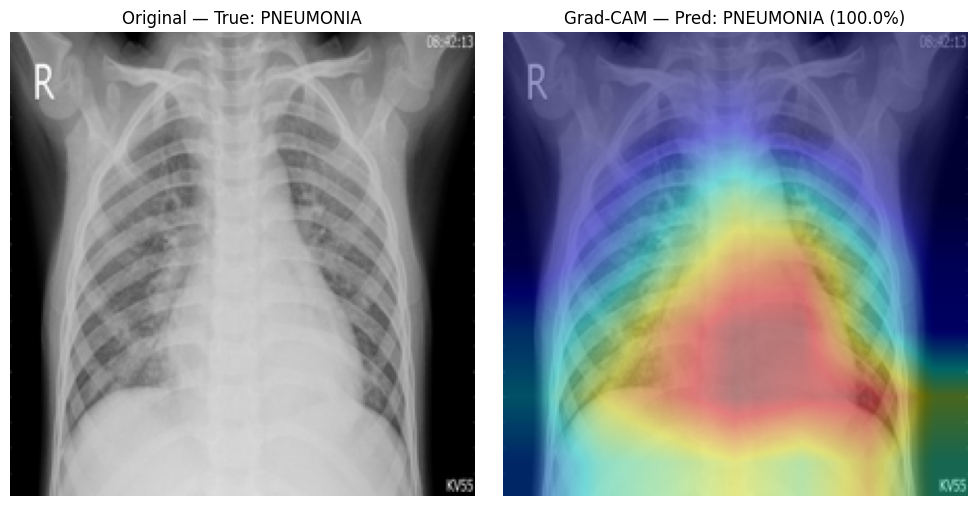

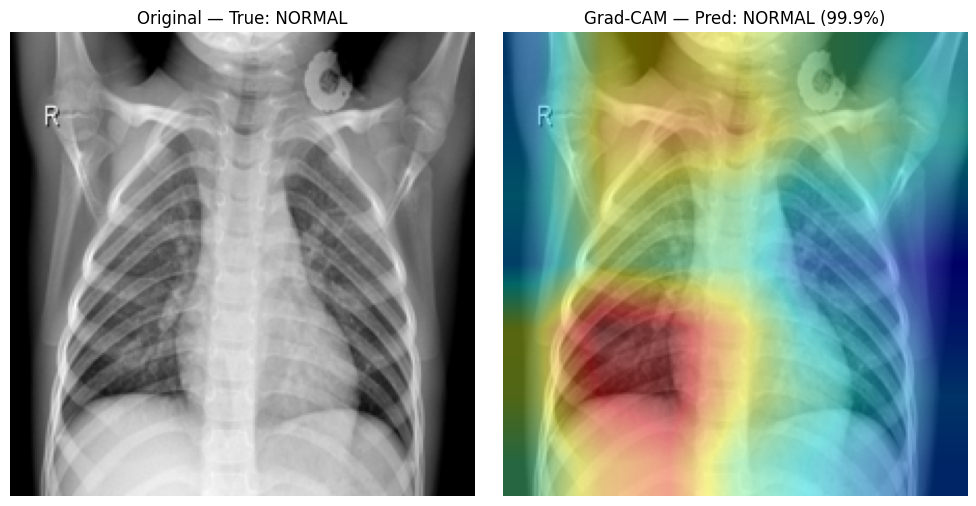

In [ ]:
import matplotlib.pyplot as plt

def show_gradcam(image_path, true_label_name):
    img = Image.open(image_path).convert("RGB")
    input_tensor = val_transforms(img).unsqueeze(0).to(device)

    heatmap, pred_idx, confidence = gradcam.generate(input_tensor)
    pred_label = train_dataset.classes[pred_idx]

    heatmap_resized = cv2.resize(heatmap, (224, 224))
    heatmap_colored = cv2.applyColorMap(np.uint8(255 * heatmap_resized), cv2.COLORMAP_JET)
    heatmap_colored = cv2.cvtColor(heatmap_colored, cv2.COLOR_BGR2RGB)

    img_resized = np.array(img.resize((224, 224)))
    overlay = cv2.addWeighted(img_resized, 0.6, heatmap_colored, 0.4, 0)

    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    axes[0].imshow(img_resized)
    axes[0].set_title(f"Original — True: {true_label_name}")
    axes[0].axis("off")
    axes[1].imshow(overlay)
    axes[1].set_title(f"Grad-CAM — Pred: {pred_label} ({confidence*100:.1f}%)")
    axes[1].axis("off")
    plt.tight_layout()
    plt.show()

# Test on one PNEUMONIA and one NORMAL image
pneumonia_dir = f"{CHEST_TEST}/PNEUMONIA"
normal_dir = f"{CHEST_TEST}/NORMAL"

show_gradcam(f"{pneumonia_dir}/{os.listdir(pneumonia_dir)[0]}", "PNEUMONIA")
show_gradcam(f"{normal_dir}/{os.listdir(normal_dir)[0]}", "NORMAL")

In [ ]:
from google.colab import files


uploaded = files.upload()


uploaded_filename = list(uploaded.keys())[0]
print("Uploaded:", uploaded_filename)

Saving images.jpg to images.jpg
Uploaded: images.jpg


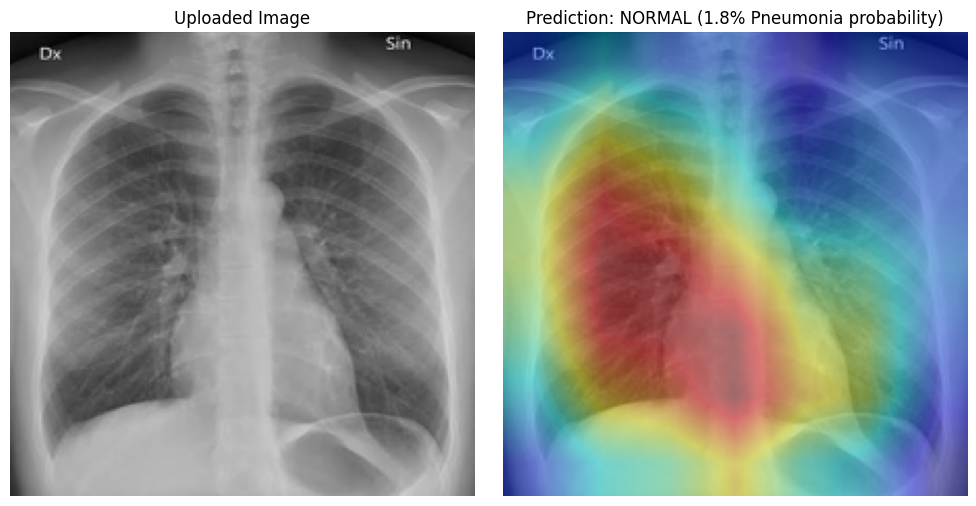

Final Prediction: NORMAL
Pneumonia Probability: 1.80%


In [ ]:
# Load the config we saved earlier (threshold + class names)
with open("chest_xray_config.json", "r") as f:
    config = json.load(f)
saved_threshold = config["threshold"]

def predict_custom_image(image_path):
    img = Image.open(image_path).convert("RGB")
    input_tensor = val_transforms(img).unsqueeze(0).to(device)

    # Get raw probability
    with torch.no_grad():
        outputs = chest_model_v2(input_tensor)
        probs = F.softmax(outputs, dim=1)
    pneumonia_prob = probs[0, 1].item()

    # Apply our tuned threshold instead of default 0.5
    final_pred = "PNEUMONIA" if pneumonia_prob >= saved_threshold else "NORMAL"

    # Generate Grad-CAM (note: this uses gradients, so no torch.no_grad() here)
    heatmap, pred_idx, _ = gradcam.generate(input_tensor)
    heatmap_resized = cv2.resize(heatmap, (224, 224))
    heatmap_colored = cv2.applyColorMap(np.uint8(255 * heatmap_resized), cv2.COLORMAP_JET)
    heatmap_colored = cv2.cvtColor(heatmap_colored, cv2.COLOR_BGR2RGB)

    img_resized = np.array(img.resize((224, 224)))
    overlay = cv2.addWeighted(img_resized, 0.6, heatmap_colored, 0.4, 0)

    # Display side by side
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    axes[0].imshow(img_resized)
    axes[0].set_title("Uploaded Image")
    axes[0].axis("off")
    axes[1].imshow(overlay)
    axes[1].set_title(f"Prediction: {final_pred} ({pneumonia_prob*100:.1f}% Pneumonia probability)")
    axes[1].axis("off")
    plt.tight_layout()
    plt.show()

    print(f"Final Prediction: {final_pred}")
    print(f"Pneumonia Probability: {pneumonia_prob*100:.2f}%")
    if pneumonia_prob >= 0.7 and pneumonia_prob < saved_threshold:
        print("Note: Model has some suspicion but below confidence threshold — recommend manual review.")

predict_custom_image(uploaded_filename)

In [ ]:
import os, shutil


if os.path.exists("brain_mri_data"):
    shutil.rmtree("brain_mri_data")
if os.path.exists("brain-tumor-mri-dataset.zip"):
    os.remove("brain-tumor-mri-dataset.zip")

!kaggle datasets download -d masoudnickparvar/brain-tumor-mri-dataset
!unzip -q brain-tumor-mri-dataset.zip -d brain_mri_data

print(os.listdir("brain_mri_data"))
print("Training classes:", os.listdir("brain_mri_data/Training"))

Dataset URL: https://www.kaggle.com/datasets/masoudnickparvar/brain-tumor-mri-dataset
License(s): Attribution 4.0 International (CC BY 4.0)
100% 157M/157M [00:09<00:00, 17.7MB/s]

['Training', 'Testing']
Training classes: ['notumor', 'meningioma', 'pituitary', 'glioma']


In [ ]:
BRAIN_TRAIN = "brain_mri_data/Training"
BRAIN_TEST  = "brain_mri_data/Testing"

# Load full training data with augmentation transforms
full_brain_train = datasets.ImageFolder(BRAIN_TRAIN, transform=train_transforms)
brain_test_dataset = datasets.ImageFolder(BRAIN_TEST, transform=val_transforms)

# Check class balance BEFORE splitting (learned this lesson from chest X-ray)
brain_class_counts = Counter(full_brain_train.targets)
print("Class distribution:", brain_class_counts)
print("Classes:", full_brain_train.classes)

# Split into train/val (85/15), same approach as chest X-ray
brain_val_size = int(0.15 * len(full_brain_train))
brain_train_size = len(full_brain_train) - brain_val_size

brain_train_subset, brain_val_subset = random_split(
    full_brain_train, [brain_train_size, brain_val_size],
    generator=torch.Generator().manual_seed(42)
)

brain_train_loader = DataLoader(brain_train_subset, batch_size=32, shuffle=True)
brain_val_loader   = DataLoader(brain_val_subset, batch_size=32, shuffle=False)
brain_test_loader  = DataLoader(brain_test_dataset, batch_size=32, shuffle=False)

print("Train size:", len(brain_train_subset))
print("Val size:", len(brain_val_subset))
print("Test size:", len(brain_test_dataset))

Class distribution: Counter({0: 1400, 1: 1400, 2: 1400, 3: 1400})
Classes: ['glioma', 'meningioma', 'notumor', 'pituitary']
Train size: 4760
Val size: 840
Test size: 1600


In [ ]:
def build_resnet_brain(num_classes=4, freeze_ratio=0.7):
    model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)

    all_params = list(model.parameters())
    freeze_upto = int(len(all_params) * freeze_ratio)

    for i, p in enumerate(all_params):
        p.requires_grad = (i >= freeze_upto)

    model.fc = nn.Sequential(
        nn.Dropout(0.4),
        nn.Linear(model.fc.in_features, 256),
        nn.ReLU(),
        nn.Linear(256, num_classes)
    )
    return model.to(device)

brain_model = build_resnet_brain(num_classes=4)
print("Brain MRI model ready. Trainable layers:", sum(p.requires_grad for p in brain_model.parameters()))

Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 179MB/s]


Brain MRI model ready. Trainable layers: 51


In [ ]:
brain_criterion = nn.CrossEntropyLoss()
brain_optimizer = optim.AdamW(filter(lambda p: p.requires_grad, brain_model.parameters()), lr=1e-4, weight_decay=1e-4)
brain_scheduler = optim.lr_scheduler.CosineAnnealingLR(brain_optimizer, T_max=10)

def train_brain_model(model, train_loader, val_loader, epochs=10):
    best_val_acc = 0
    for epoch in range(epochs):
        model.train()
        train_loss, train_correct, train_total = 0, 0, 0
        for imgs, labels in train_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            brain_optimizer.zero_grad()
            outputs = model(imgs)
            loss = brain_criterion(outputs, labels)
            loss.backward()
            brain_optimizer.step()
            train_loss += loss.item()
            train_correct += (outputs.argmax(1) == labels).sum().item()
            train_total += labels.size(0)

        model.eval()
        val_loss, val_correct, val_total = 0, 0, 0
        with torch.no_grad():
            for imgs, labels in val_loader:
                imgs, labels = imgs.to(device), labels.to(device)
                outputs = model(imgs)
                loss = brain_criterion(outputs, labels)
                val_loss += loss.item()
                val_correct += (outputs.argmax(1) == labels).sum().item()
                val_total += labels.size(0)

        brain_scheduler.step()
        train_acc = train_correct / train_total
        val_acc = val_correct / val_total
        # Gap between train and val accuracy tells us about overfitting
        gap = train_acc - val_acc
        print(f"Epoch {epoch+1}/{epochs} | Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f} | Gap: {gap:.4f}")

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), "brain_mri_resnet50_best.pth")
            print(f"  -> New best model saved (Val Acc: {val_acc:.4f})")

    return model

print("Training Brain MRI model...")
brain_model = train_brain_model(brain_model, brain_train_loader, brain_val_loader, epochs=10)

Training Brain MRI model...
Epoch 1/10 | Train Acc: 0.8830 | Val Acc: 0.9655 | Gap: -0.0825
  -> New best model saved (Val Acc: 0.9655)
Epoch 2/10 | Train Acc: 0.9595 | Val Acc: 0.9679 | Gap: -0.0084
  -> New best model saved (Val Acc: 0.9679)
Epoch 3/10 | Train Acc: 0.9809 | Val Acc: 0.9786 | Gap: 0.0023
  -> New best model saved (Val Acc: 0.9786)
Epoch 4/10 | Train Acc: 0.9853 | Val Acc: 0.9833 | Gap: 0.0020
  -> New best model saved (Val Acc: 0.9833)
Epoch 5/10 | Train Acc: 0.9893 | Val Acc: 0.9810 | Gap: 0.0083
Epoch 6/10 | Train Acc: 0.9920 | Val Acc: 0.9786 | Gap: 0.0134
Epoch 7/10 | Train Acc: 0.9952 | Val Acc: 0.9881 | Gap: 0.0071
  -> New best model saved (Val Acc: 0.9881)
Epoch 8/10 | Train Acc: 0.9971 | Val Acc: 0.9845 | Gap: 0.0125
Epoch 9/10 | Train Acc: 0.9968 | Val Acc: 0.9845 | Gap: 0.0123
Epoch 10/10 | Train Acc: 0.9983 | Val Acc: 0.9881 | Gap: 0.0102


In [ ]:
brain_model.load_state_dict(torch.load("brain_mri_resnet50_best.pth"))
brain_model.eval()

brain_all_preds = []
brain_all_labels = []

with torch.no_grad():
    for imgs, labels in brain_test_loader:
        imgs = imgs.to(device)
        outputs = brain_model(imgs)
        preds = outputs.argmax(1).cpu().numpy()
        brain_all_preds.extend(preds)
        brain_all_labels.extend(labels.numpy())

print("BRAIN MRI TEST SET RESULTS (unbiased, true performance):")
print(classification_report(brain_all_labels, brain_all_preds, target_names=full_brain_train.classes))

print("Confusion Matrix:")
print(confusion_matrix(brain_all_labels, brain_all_preds))

BRAIN MRI TEST SET RESULTS (unbiased, true performance):
              precision    recall  f1-score   support

      glioma       0.99      0.80      0.88       400
  meningioma       0.88      0.99      0.93       400
     notumor       0.93      1.00      0.97       400
   pituitary       1.00      1.00      1.00       400

    accuracy                           0.95      1600
   macro avg       0.95      0.95      0.94      1600
weighted avg       0.95      0.95      0.94      1600

Confusion Matrix:
[[319  54  27   0]
 [  2 395   1   2]
 [  0   0 400   0]
 [  0   1   0 399]]


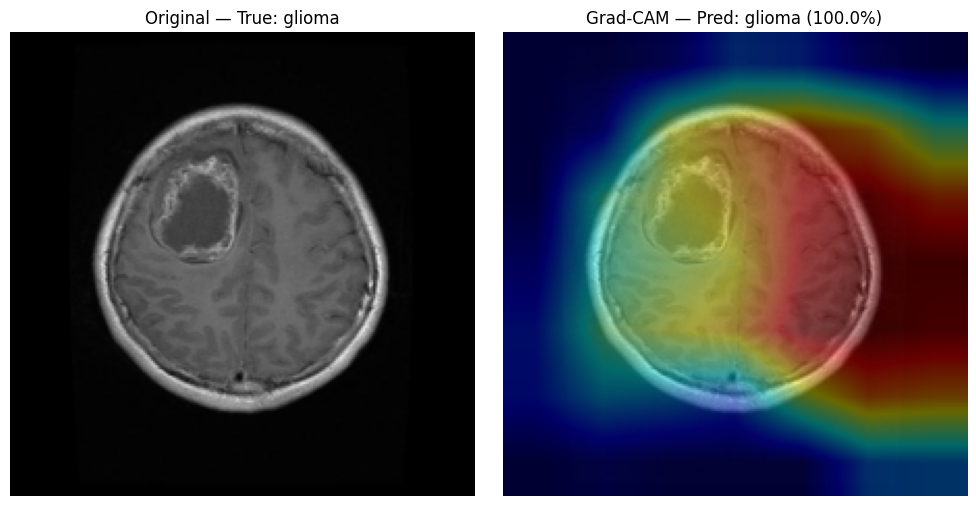

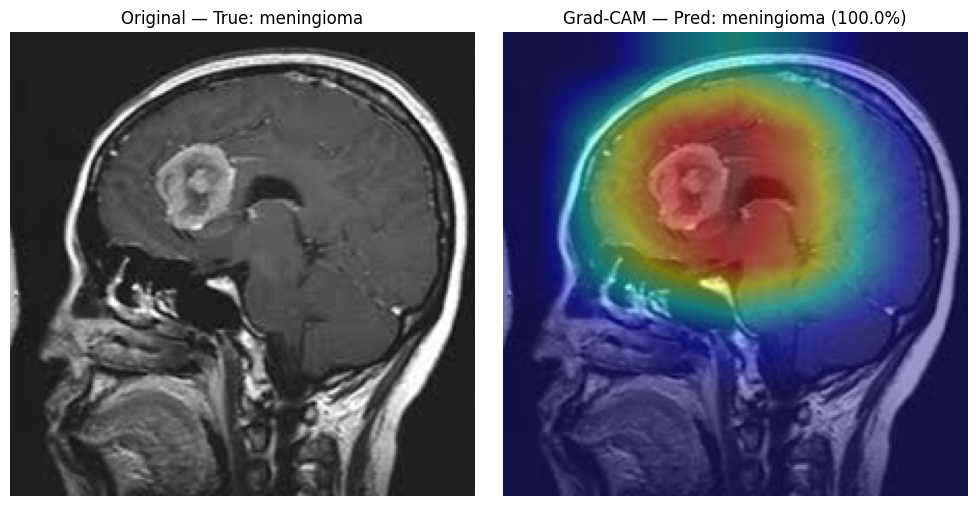

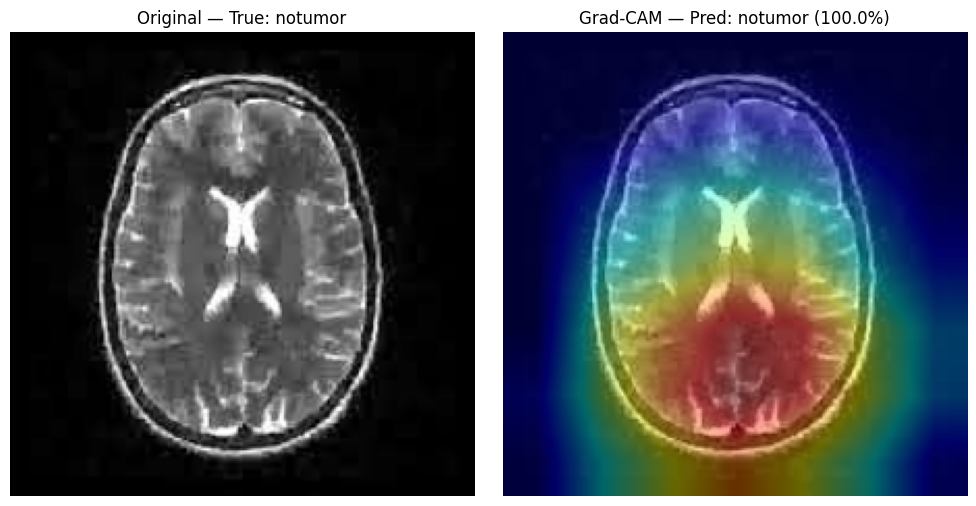

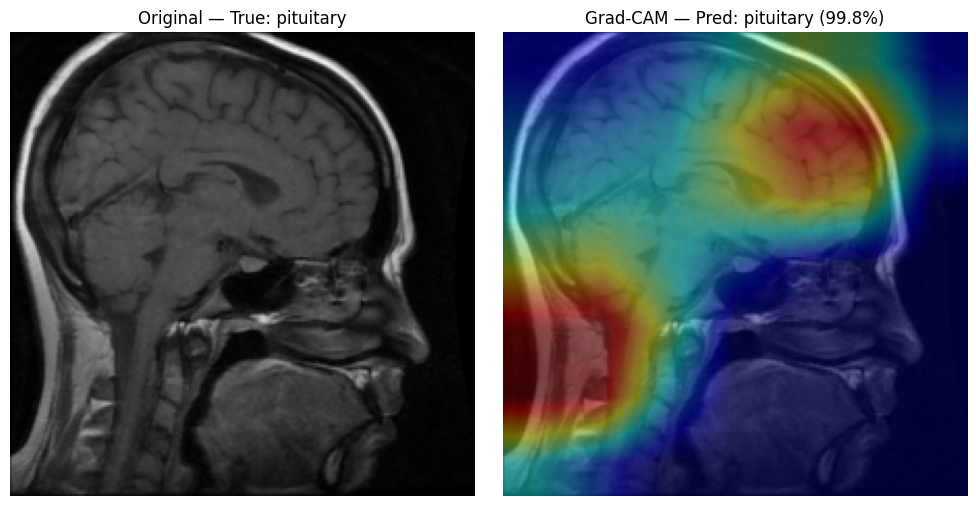

In [ ]:
class GradCAMBrain:
    def __init__(self, model, target_layer):
        self.model = model
        self.gradients = None
        self.activations = None
        target_layer.register_forward_hook(self._save_activation)
        target_layer.register_full_backward_hook(self._save_gradient)

    def _save_activation(self, module, input, output):
        self.activations = output.detach()

    def _save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].detach()

    def generate(self, input_tensor):
        output = self.model(input_tensor)
        probs = F.softmax(output, dim=1)
        class_idx = output.argmax(dim=1).item()

        self.model.zero_grad()
        output[0, class_idx].backward()

        pooled_gradients = torch.mean(self.gradients, dim=[0, 2, 3])
        activations = self.activations[0]
        for i in range(activations.shape[0]):
            activations[i, :, :] *= pooled_gradients[i]

        heatmap = torch.mean(activations, dim=0).cpu().numpy()
        heatmap = np.maximum(heatmap, 0)
        heatmap /= (np.max(heatmap) + 1e-8)
        return heatmap, class_idx, probs[0, class_idx].item()

# Last conv layer of ResNet-50
brain_target_layer = brain_model.layer4[-1].conv3
gradcam_brain = GradCAMBrain(brain_model, brain_target_layer)

def show_gradcam_brain(image_path, true_label_name):
    img = Image.open(image_path).convert("RGB")
    input_tensor = val_transforms(img).unsqueeze(0).to(device)

    heatmap, pred_idx, confidence = gradcam_brain.generate(input_tensor)
    pred_label = full_brain_train.classes[pred_idx]

    heatmap_resized = cv2.resize(heatmap, (224, 224))
    heatmap_colored = cv2.applyColorMap(np.uint8(255 * heatmap_resized), cv2.COLORMAP_JET)
    heatmap_colored = cv2.cvtColor(heatmap_colored, cv2.COLOR_BGR2RGB)

    img_resized = np.array(img.resize((224, 224)))
    overlay = cv2.addWeighted(img_resized, 0.6, heatmap_colored, 0.4, 0)

    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    axes[0].imshow(img_resized)
    axes[0].set_title(f"Original — True: {true_label_name}")
    axes[0].axis("off")
    axes[1].imshow(overlay)
    axes[1].set_title(f"Grad-CAM — Pred: {pred_label} ({confidence*100:.1f}%)")
    axes[1].axis("off")
    plt.tight_layout()
    plt.show()

# Show one example per class
for cls in full_brain_train.classes:
    cls_dir = f"{BRAIN_TEST}/{cls}"
    show_gradcam_brain(f"{cls_dir}/{os.listdir(cls_dir)[0]}", cls)

In [ ]:
from google.colab import files

uploaded_brain = files.upload()
uploaded_brain_filename = list(uploaded_brain.keys())[0]
print("Uploaded:", uploaded_brain_filename)

Saving images (3).jpg to images (3).jpg
Uploaded: images (3).jpg


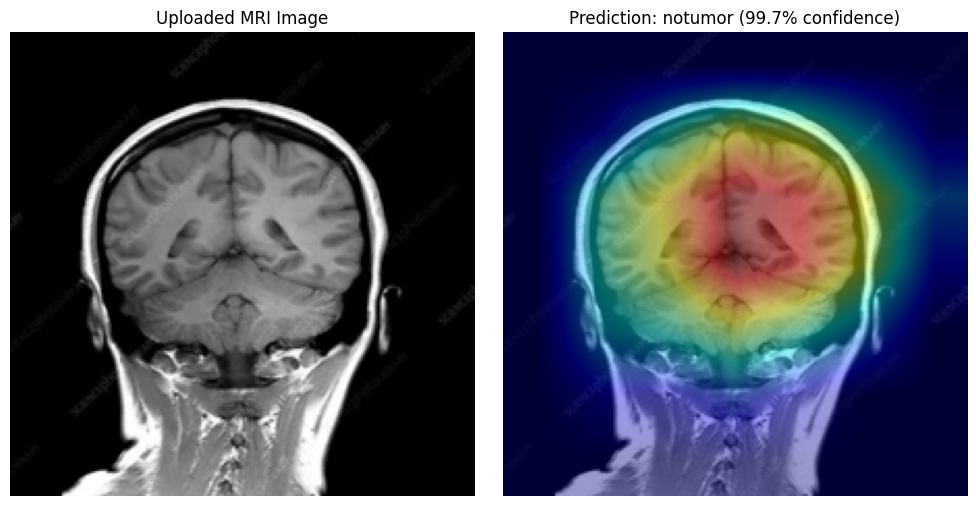

Final Prediction: notumor
Confidence: 99.69%


In [ ]:
def predict_custom_brain_mri(image_path):
    img = Image.open(image_path).convert("RGB")
    input_tensor = val_transforms(img).unsqueeze(0).to(device)

    heatmap, pred_idx, confidence = gradcam_brain.generate(input_tensor)
    pred_label = full_brain_train.classes[pred_idx]

    heatmap_resized = cv2.resize(heatmap, (224, 224))
    heatmap_colored = cv2.applyColorMap(np.uint8(255 * heatmap_resized), cv2.COLORMAP_JET)
    heatmap_colored = cv2.cvtColor(heatmap_colored, cv2.COLOR_BGR2RGB)

    img_resized = np.array(img.resize((224, 224)))
    overlay = cv2.addWeighted(img_resized, 0.6, heatmap_colored, 0.4, 0)

    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    axes[0].imshow(img_resized)
    axes[0].set_title("Uploaded MRI Image")
    axes[0].axis("off")
    axes[1].imshow(overlay)
    axes[1].set_title(f"Prediction: {pred_label} ({confidence*100:.1f}% confidence)")
    axes[1].axis("off")
    plt.tight_layout()
    plt.show()

    print(f"Final Prediction: {pred_label}")
    print(f"Confidence: {confidence*100:.2f}%")

predict_custom_brain_mri(uploaded_brain_filename)

In [ ]:
import numpy as np, torch, json
import torch.nn.functional as F
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, Subset
from torchvision import datasets

@torch.no_grad()
def collect_logits(model, loader):
    model.eval()
    L, Y = [], []
    for x, y in loader:
        L.append(model(x.to(device)).cpu())
        Y.append(y)
    return torch.cat(L), torch.cat(Y)

def ece_score(probs, labels, n_bins=10):
    """Expected Calibration Error: confidence aur actual accuracy ka average gap."""
    conf, pred = probs.max(1)
    acc = (pred == labels).float()
    edges = torch.linspace(0, 1, n_bins + 1)
    ece = 0.0
    for lo, hi in zip(edges[:-1], edges[1:]):
        m = (conf > lo) & (conf <= hi)
        if m.any():
            ece += m.float().mean().item() * abs(acc[m].mean().item() - conf[m].mean().item())
    return ece

def brier_score(probs, labels):
    onehot = F.one_hot(labels, probs.shape[1]).float()
    return ((probs - onehot) ** 2).sum(1).mean().item()

def fit_temperature(logits, labels):
    """Temperature scaling: SIRF validation set par fit hota hai, test par kabhi nahi."""
    T = torch.nn.Parameter(torch.ones(1))
    opt = torch.optim.LBFGS([T], lr=0.1, max_iter=200)
    def closure():
        opt.zero_grad()
        loss = F.cross_entropy(logits / T, labels)
        loss.backward()
        return loss
    opt.step(closure)
    return T.item()

def reliability_panel(ax, probs, labels, title, n_bins=10):
    conf, pred = probs.max(1)
    acc = (pred == labels).float()
    edges = torch.linspace(0, 1, n_bins + 1)
    xs, ys, counts = [], [], []
    for lo, hi in zip(edges[:-1], edges[1:]):
        m = (conf > lo) & (conf <= hi)
        if m.sum() > 0:
            xs.append(conf[m].mean().item()); ys.append(acc[m].mean().item()); counts.append(int(m.sum()))
    ax.plot([0, 1], [0, 1], "--", color="#0a0f1a", label="Perfect calibration")
    ax.plot(xs, ys, "o-", color="#1d6fff", label="Model")
    for x, y, c in zip(xs, ys, counts):
        ax.annotate(str(c), (x, y), textcoords="offset points", xytext=(0, 7), ha="center", fontsize=7)
    ax.set_xlim(0, 1); ax.set_ylim(0, 1.05)
    ax.set_xlabel("Mean confidence"); ax.set_ylabel("Actual accuracy")
    ax.set_title(f"{title}\nECE = {ece_score(probs, labels):.3f}", fontsize=10)
    ax.legend(loc="upper left", fontsize=8); ax.grid(alpha=0.25)

def calibration_audit(name, val_logits, val_y, test_logits, test_y):
    T = fit_temperature(val_logits, val_y)
    p_raw = F.softmax(test_logits, 1)
    p_cal = F.softmax(test_logits / T, 1)
    conf_raw, pred = p_raw.max(1)
    correct = pred == test_y
    print(f"\n===== {name} =====")
    print(f"Test accuracy                : {correct.float().mean().item():.4f}")
    print(f"Fitted temperature T (val)   : {T:.3f}   (T>1 = model overconfident tha)")
    print(f"ECE   raw -> calibrated      : {ece_score(p_raw, test_y):.4f} -> {ece_score(p_cal, test_y):.4f}")
    print(f"Brier raw -> calibrated      : {brier_score(p_raw, test_y):.4f} -> {brier_score(p_cal, test_y):.4f}")
    print(f"NLL   raw -> calibrated      : {F.cross_entropy(test_logits, test_y).item():.4f} -> {F.cross_entropy(test_logits / T, test_y).item():.4f}")
    print(f"Mean confidence (correct)    : {conf_raw[correct].mean().item():.3f}")
    if (~correct).any():
        print(f"Mean confidence (WRONG)      : {conf_raw[~correct].mean().item():.3f}")
    hc_wrong = ((conf_raw >= 0.9) & ~correct).sum().item()
    hc_total = (conf_raw >= 0.9).sum().item()
    print(f"Wrong predictions at >=90% confidence: {hc_wrong} of {hc_total} high-confidence predictions")
    fig, axes = plt.subplots(1, 2, figsize=(11, 4.6))
    reliability_panel(axes[0], p_raw, test_y, f"{name}: before")
    reliability_panel(axes[1], p_cal, test_y, f"{name}: after temperature scaling (T={T:.2f})")
    plt.tight_layout()
    plt.savefig(f"reliability_{name.replace(' ', '_').lower()}.png", dpi=160)
    plt.show()
    return T



===== Brain MRI =====
Test accuracy                : 0.9456
Fitted temperature T (val)   : 1.323   (T>1 = model overconfident tha)
ECE   raw -> calibrated      : 0.0427 -> 0.0363
Brier raw -> calibrated      : 0.0944 -> 0.0909
NLL   raw -> calibrated      : 0.3498 -> 0.2754
Mean confidence (correct)    : 0.995
Mean confidence (WRONG)      : 0.876
Wrong predictions at >=90% confidence: 52 of 1547 high-confidence predictions


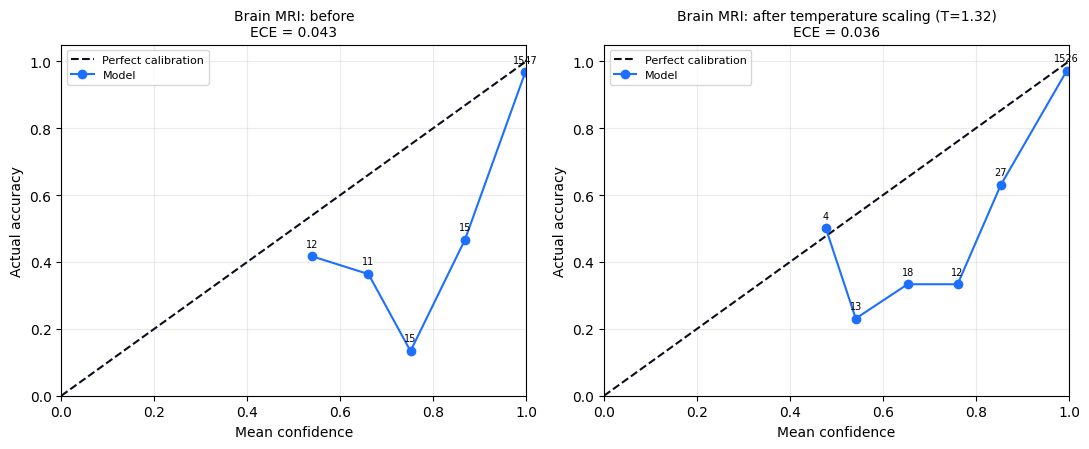

In [ ]:
brain_val_clean = Subset(datasets.ImageFolder(BRAIN_TRAIN, transform=val_transforms),
                         brain_val_subset.indices)
brain_val_clean_loader = DataLoader(brain_val_clean, batch_size=32, shuffle=False)

bv_logits, bv_y = collect_logits(brain_model, brain_val_clean_loader)
bt_logits, bt_y = collect_logits(brain_model, brain_test_loader)
T_brain = calibration_audit("Brain MRI", bv_logits, bv_y, bt_logits, bt_y)



===== Chest X-ray =====
Test accuracy                : 0.8606
Fitted temperature T (val)   : 1.059   (T>1 = model overconfident tha)
ECE   raw -> calibrated      : 0.1108 -> 0.1087
Brier raw -> calibrated      : 0.2503 -> 0.2485
NLL   raw -> calibrated      : 0.6481 -> 0.6167
Mean confidence (correct)    : 0.974
Mean confidence (WRONG)      : 0.919
Wrong predictions at >=90% confidence: 61 of 554 high-confidence predictions


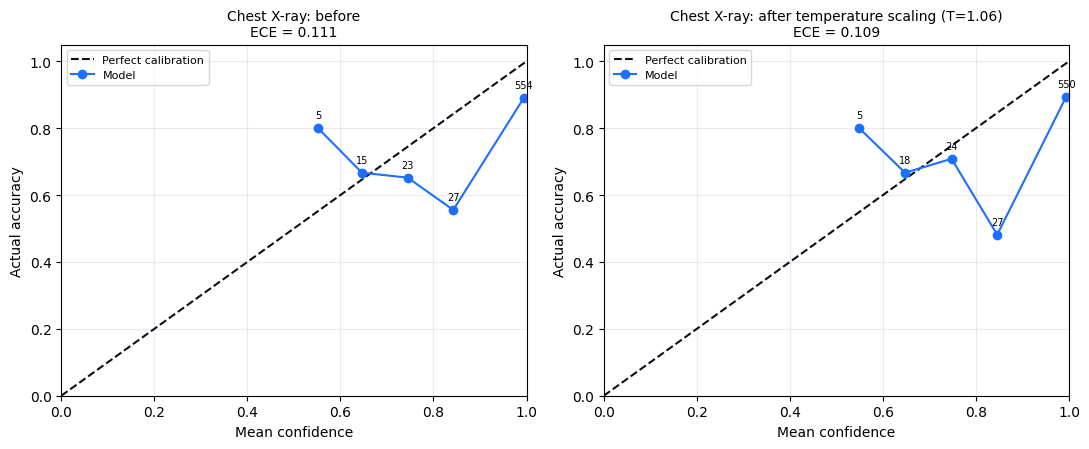


Saved calibration_config.json


In [ ]:
chest_val_clean = Subset(datasets.ImageFolder(CHEST_TRAIN, transform=val_transforms),
                         val_subset.indices)
chest_val_clean_loader = DataLoader(chest_val_clean, batch_size=32, shuffle=False)

cv_logits, cv_y = collect_logits(chest_model_v2, chest_val_clean_loader)
ct_logits, ct_y = collect_logits(chest_model_v2, test_loader)
T_chest = calibration_audit("Chest X-ray", cv_logits, cv_y, ct_logits, ct_y)

with open("calibration_config.json", "w") as f:
    json.dump({"brain_temperature": T_brain, "chest_temperature": T_chest,
               "fitted_on": "clean validation split (no augmentation), never on test"}, f, indent=2)
print("\nSaved calibration_config.json")

In [ ]:
print("Chest ECE on VAL :", round(ece_score(F.softmax(cv_logits, 1), cv_y), 4))
print("Chest ECE on TEST:", round(ece_score(F.softmax(ct_logits, 1), ct_y), 4))
print("Brain ECE on VAL :", round(ece_score(F.softmax(bv_logits, 1), bv_y), 4))
print("Brain ECE on TEST:", round(ece_score(F.softmax(bt_logits, 1), bt_y), 4))

Chest ECE on VAL : 0.0068
Chest ECE on TEST: 0.1108
Brain ECE on VAL : 0.0108
Brain ECE on TEST: 0.0427


In [ ]:
needed = ["vectorizer", "text_model", "chest_model_v2", "saved_threshold",
          "gradcam", "gradcam_brain", "full_brain_train", "val_transforms", "device"]
print({n: (n in globals()) for n in needed})

{'vectorizer': True, 'text_model': True, 'chest_model_v2': True, 'saved_threshold': True, 'gradcam': True, 'gradcam_brain': True, 'full_brain_train': True, 'val_transforms': True, 'device': True}


In [ ]:
# ==========================================================================
# CELL A: Wary Agents
# ==========================================================================
import re, time, json, uuid
import numpy as np


AUDIT_CFG = dict(
    min_conf=0.50,
    min_margin=0.10,
    vulnerable_conf=0.65,
    vulnerable_young=5,
    vulnerable_old=65,
    min_info_nnz=3,
)


RED_FLAGS = [
    ("chest_pain", "chest pain or pressure", "seene mein dard ya dabao", [
        r"\b(seene|seena|sine|sina|chhati|chati|dil)\b.{0,25}\b(dard|dabao|bhari|bhaari|bojh|pain)\b",
        r"\bchest\b.{0,25}\b(pain|pressure|tight\w*|crush\w*)\b", r"\bheart attack\b",
        r"سینے.{0,15}(درد|دباؤ)", r"دل کا دورہ"]),
    ("breathing", "severe difficulty breathing", "saans lene mein shadeed mushkil", [
        r"\b(saans|sans)\b.{0,25}\b(phool\w*|ruk\w*|band|mushkil|takleef|tang)\b",
        r"\b(saans|sans)\s+(nahi|nahin|nhi)\s+(aa|aati|aata|le|li)\w*",
        r"\b(short(ness)? of breath|can'?t breathe|cannot breathe|difficulty breathing|trouble breathing|breathless\w*|gasping)\b",
        r"سانس.{0,15}(نہیں|پھول|مشکل|تکلیف)"]),
    ("stroke", "possible stroke signs", "stroke ki alamat (chehra tirha, zubaan larkharana, ek taraf kamzori)", [
        r"\b(chehra|chehre|munh|muh|face)\b.{0,25}\b(tirha|terha|tedha|latk\w*|drooping|droop\w*|numb|sun)\b",
        r"\b(zubaan|zuban|bolne)\b.{0,25}\b(lar\w*|ruk\w*|nahi|slur\w*|mushkil)\b",
        r"\b(ek taraf|one side)\b.{0,25}\b(kamzori|kamzor|sun|numb|weak\w*|paralys\w*|falij)\b",
        r"\b(stroke|falij|laqwa|lakwa|paralys\w*|slurred speech)\b",
        r"(چہرہ|منہ).{0,12}(ٹیڑھا|ٹیڑھ)", r"زبان.{0,12}(لڑکھڑا|بند)"]),
    ("bleeding", "heavy or unusual bleeding", "bohat ya ghair mamooli khoon behna", [
        r"\b(khoon|blood)\b.{0,25}\b(ulti|ultiyan|vomit\w*|nahi ruk\w*|bohat|bahut|zyada|heavy|profuse)\b",
        r"\b(bohat|bahut|zyada|heavy)\b.{0,15}\b(khoon|blood)\b", r"\bkhoon\b.{0,15}\b(beh|bah|nikal)\w*",
        r"\b(vomit\w* blood|khooni ulti|blood in (stool|vomit)|kala pakhana|black stool)\b",
        r"خون.{0,12}(الٹی|بہہ|بہ )"]),
    ("unconscious", "loss of consciousness", "behoshi", [
        r"\b(behosh|bayhosh|hosh\s*(nahi|nahin|kho)\w*|unconscious|fainted|passed out|collapsed|unresponsive)\b",
        r"بے ?ہوش"]),
    ("seizure", "seizure or convulsions", "daura ya jhatke", [
        r"\b(mirgi|seizure|convuls\w*|jhatke|jhatka|daura par\w*|dora par\w*)\b", r"(مرگی|جھٹکے)"]),
    ("allergy", "severe allergic reaction", "shadeed allergy (zubaan/hont/gale mein sujan)", [
        r"\b(allergic reaction|anaphyla\w*|throat (swelling|closing)|zubaan (sooj|suj)\w*|hont (sooj|suj)\w*)\b"]),
    ("poisoning", "poisoning or overdose", "zehar ya zyada dawa kha lena", [
        r"\b(zehr|zeher|zahar|poison\w*|overdose|kerosene)\b", r"زہر"]),
    ("pregnancy", "pregnancy with bleeding or severe pain", "hamal mein khoon ya shadeed dard", [
        r"\b(hamal|hamla|haamla|pregnan\w*)\b.{0,40}\b(khoon|bleed\w*|bohat dard|shadeed dard|severe pain)\b",
        r"\b(khoon|bleed\w*)\b.{0,40}\b(hamal|hamla|haamla|pregnan\w*)\b"]),
    ("self_harm", "thoughts of self-harm", "khud ko nuqsan pohanchane ke khayalat", [
        r"\b(khudkushi|khud kushi|suicide|suicidal|jaan dena|apni jaan|marna chahta|marna chahti|mar jana chahta|mar jana chahti|kill myself|end my life|want to die)\b",
        r"خودکشی"]),
]
_RF_COMPILED = [(k, en, ur, [re.compile(p, re.I) for p in pats]) for k, en, ur, pats in RED_FLAGS]

def _norm(text):
    t = str(text or "").lower()
    t = re.sub(r"[^\w\s']", " ", t)
    return re.sub(r"\s+", " ", t).strip()

_NEG_AFTER = re.compile(r"^\s*(hai\s+|hain\s+)?(nahi|nahin|nhi)\b")
_NEG_BEFORE = re.compile(r"\b(no|not|without|never|nahi|nahin|nhi)\s+(\w+\s+)?$")

def detect_red_flags(text):
    """Emergency alamat dhoondta hai. Simple negation ("dard nahi hai", "no chest pain") ko ignore karta hai,
    lekin shak ho to ESCALATE karta hai (false alarm theek hai, missed emergency nahi)."""
    t = _norm(text)
    found, seen = [], set()
    for key, en, ur, pats in _RF_COMPILED:
        for p in pats:
            m = p.search(t)
            if not m or key in seen:
                continue
            after, before = t[m.end():m.end() + 14], t[max(0, m.start() - 14):m.start()]
            if _NEG_AFTER.match(after) or _NEG_BEFORE.search(before):
                continue
            seen.add(key)
            found.append(dict(key=key, label=en, label_ur=ur, snippet=m.group(0)[:60]))
    return found

# ---------- Roman Urdu -> English symptom lexicon (symptom model English par train hua hai) ----------
LEXICON = [
    (r"\b(sar|sir)\s*(mein|me|main|ma)?\s*dard\b|\b(sar|sir)dard\b|\bheadache\b", "headache"),
    (r"\b(bukhar|bukhaar|bokhar|fever|temperature)\b", "fever"),
    (r"\b(khansi|khaansi|khasi|cough\w*)\b", "cough"),
    (r"\b(zukam|zukaam|nazla|nazle|runny nose|cold)\b", "cold and runny nose"),
    (r"\b(gala|gale|galay)\s*(mein|me|main|ma)?\s*(kharab|dard|kharash|kharaash|sooj\w*)\b|\bsore throat\b|\bthroat pain\b", "sore throat"),
    (r"\b(pait|pet|peit)\s*(mein|me|main|ma)?\s*(dard|marror|maror)\b|\b(stomach|abdominal|belly)\s*(pain|ache)\b|\bstomach ache\b", "stomach pain"),
    (r"\b(ulti|ultiyan|ultee|qay|vomit\w*)\b", "vomiting"),
    (r"\b(matli|mitli|nausea|nauseous)\b", "nausea"),
    (r"\b(dast|patle pakhane|loose motions?|diarrh?oea|diarrhea)\b", "diarrhea"),
    (r"\b(qabz|kabz|constipation)\b", "constipation"),
    (r"\b(jism|badan|body)\s*(mein|me|main|ma)?\s*(dard|pain|ache\w*)\b|\bbody ache\w*\b", "body aches"),
    (r"\b(jod|jodon|jodo|joron|joro|joints?)\s*(mein|me|main|ma|ka|ke|ki)?\s*(dard|pain|akar\w*|stiff\w*|swelling)\b|\bjoint pain\b", "joint pain"),
    (r"\b(kamar|kamr|back)\s*(mein|me|main|ma)?\s*(dard|pain|ache)\b", "back pain"),
    (r"\b(kamzori|kamzor|weakness|weak)\b", "weakness"),
    (r"\b(thakan|thakawat|thaka|fatigue|tired\w*|exhaust\w*)\b", "fatigue"),
    (r"\b(chakkar|chakar|dizz\w*|vertigo)\b", "dizziness"),
    (r"\b(khujli|kharish|kharash|itch\w*)\b", "itching"),
    (r"\b(daane|dane|dhabbe|dhabe|rash\w*)\b", "skin rash"),
    (r"\b(peshab|pishab)\s*(mein|me|main|ma)?\s*(jalan|dard|takleef)\b|\bburning urination\b|\bpainful urination\b", "burning urination"),
    (r"\b(bar bar|baar baar|frequent)\s*(peshab|pishab|urinat\w*)\b", "frequent urination"),
    (r"\b(pyaas|pyas|excessive thirst)\b", "excessive thirst"),
    (r"\b(bhook|bhuk)\s*(nahi|nahin|kam|nhi)\b|\bloss of appetite\b", "loss of appetite"),
    (r"\b(peeli|peela|pili|pila)\s*(aankh\w*|ankh\w*|rang|jild|skin)\b|\byellow(ish)? (eyes|skin)\b|\bjaundice\b", "yellow skin and eyes"),
    (r"\b(seene|sine|seena)\s*(mein|me|main|ma)?\s*jalan\b|\b(khatti dakar|khatti dakaar|dakar|acidity|heartburn|acid reflux)\b", "heartburn and acid reflux"),
    (r"\b(kapkapi|kampkampi|kanpna|chills?|shiver\w*)\b", "chills"),
    (r"\b(pasina|pasine|sweating|sweats?)\b", "sweating"),
    (r"\b(kaan|kan)\s*(mein|me|main|ma)?\s*dard\b|\bear ?ache\b", "ear pain"),
    (r"\b(daant|dant)\s*(mein|me|main|ma)?\s*dard\b|\btooth ?ache\b", "toothache"),
    (r"\b(naak|naq)\s*(band|behna|beh)\w*|\bnasal congestion\b|\bblocked nose\b", "nasal congestion"),
    (r"\b(seene|sine|seena|chest)\s*(mein|me|main|ma)?\s*(dard|pain|tight\w*)\b", "chest pain"),
    (r"\b(saans|sans)\s*(phool\w*|ki takleef|lene mein)\b|\bshort(ness)? of breath\b|\bbreathless\w*\b|\bwheez\w*\b", "shortness of breath"),
    (r"\b(muhasay|muhase|pimples?|acne)\b", "acne"),
    (r"\b(sujan|sooj\w*|swell\w*)\b", "swelling"),
    (r"\b(nind nahi|neend nahi|insomnia)\b", "insomnia"),
]
_LEX_COMPILED = [(re.compile(p, re.I), en) for p, en in LEXICON]
_UR_MARKERS = {"mein", "mujhe", "hai", "hain", "raha", "rahi", "bohat", "bahut", "aur", "nahi", "kal", "din", "mera", "meri",
               "ho", "gaya", "gayi", "se", "hua", "hui", "thora", "thori", "bhi"}
_DUR = re.compile(r"(\d+)\s*(din|days?|hafta|haftay|hafte|weeks?|mahina|mahine|months?|ghante|hours?)", re.I)

def _rule_intake(text):
    t = _norm(text)
    phrases = []
    for rx, en in _LEX_COMPILED:
        if rx.search(t) and en not in phrases:
            phrases.append(en)
    toks = t.split()
    if re.search(r"[\u0600-\u06FF]", str(text or "")):
        lang = "urdu"
    elif sum(1 for w in toks if w in _UR_MARKERS) >= 2:
        lang = "roman_urdu"
    else:
        lang = "english"
    dur = _DUR.search(t)
    return dict(symptoms=phrases, lang=lang, duration=(f"{dur.group(1)} {dur.group(2)}" if dur else None),
                english_text=(t + " " + ", ".join(phrases)).strip(), source="rules")

def _parse_json(txt):
    txt = re.sub(r"^```(?:json)?|```$", "", txt.strip(), flags=re.M).strip()
    return json.loads(txt)

def intake_agent(text, gemini=None):
    """Agent 1: Roman Urdu / Urdu / English complaint ko structured symptoms mein badalta hai.
    Gemini ho to usse bhi use karta hai, warna rules. Red flags yahan se NAHI nikalte (Auditor raw text dekhta hai)."""
    base = _rule_intake(text)
    if gemini is None:
        return base
    try:
        prompt = ("Convert this patient message (Roman Urdu, Urdu, English or mixed) to JSON ONLY, no markdown, with keys: "
                  "english_text (plain English description of the symptoms only, no diagnosis), "
                  "symptoms (list of short English symptom phrases), duration (string or null). "
                  "Do not diagnose or add symptoms that are not mentioned.\nMessage: " + str(text)[:1000])
        data = _parse_json(gemini.generate_content(prompt).text)
        eng = str(data.get("english_text", ""))[:500].strip()
        syms = [str(s).strip().lower() for s in (data.get("symptoms") or []) if str(s).strip()][:15]
        if eng:
            merged = list(dict.fromkeys(base["symptoms"] + syms))
            base.update(english_text=(eng + " " + ", ".join(merged)).strip(), symptoms=merged,
                        duration=data.get("duration") or base["duration"], source="gemini+rules")
    except Exception as e:
        print("Intake Gemini fallback to rules:", type(e).__name__)
    return base

def specialist_agent(english_text, vectorizer, text_model, k=3):
    """Agent 2: tumhara trained symptom model. Top-k predictions + raw scores."""
    vec = vectorizer.transform([english_text])
    proba = text_model.predict_proba(vec)[0]
    order = np.argsort(proba)[::-1][:k]
    return dict(top=[(str(text_model.classes_[i]), float(proba[i])) for i in order], nnz=int(vec.nnz))

def audit(raw_text, intake, spec, age, imaging_log=None, cfg=None):
    """Agent 3: SAFETY AUDITOR. Faisla karta hai ke jawab dena hai, abstain karna hai ya emergency escalate karni hai."""
    cfg = {**AUDIT_CFG, **(cfg or {})}
    flags = detect_red_flags(raw_text)
    reasons = []
    top = spec["top"]
    conf = top[0][1]
    margin = conf - top[1][1] if len(top) > 1 else conf
    age_n = int(str(age).strip()) if str(age).strip().isdigit() else None
    vulnerable = age_n is not None and (age_n < cfg["vulnerable_young"] or age_n >= cfg["vulnerable_old"])
    need = cfg["vulnerable_conf"] if vulnerable else cfg["min_conf"]
    imaging_risk = [e for e in (imaging_log or []) if e.get("module") in ("Chest X-ray", "Brain MRI") and e.get("state") == "risk"]

    if flags:
        for f in flags:
            reasons.append(("red_flag", f"Red flag: {f['label']} (matched '{f['snippet']}')"))
        decision = "EMERGENCY"
    else:
        if spec["nnz"] < cfg["min_info_nnz"] and len(intake["symptoms"]) < 2:
            reasons.append(("low_info", "Too little symptom information to reason safely"))
        if conf < need:
            code = "vulnerable_age" if (vulnerable and conf >= cfg["min_conf"]) else "low_conf"
            msg = (f"Model score {conf*100:.0f}% is below the required {need*100:.0f}%" +
                   (" (stricter threshold for age under 5 or 65 and above)" if vulnerable else ""))
            reasons.append((code, msg))
        if margin < cfg["min_margin"]:
            reasons.append(("low_margin", f"Top-2 conditions are too close ({top[0][0]} vs {top[1][0]}, gap {margin*100:.0f} points)"))
        if imaging_risk:
            reasons.append(("imaging", "Imaging flagged in this session: " + ", ".join(f"{e['module']}: {e['result']}" for e in imaging_risk)))
        blocking = [r for r in reasons if r[0] in ("low_info", "low_conf", "vulnerable_age", "low_margin")]
        if blocking:
            decision = "ABSTAIN"
        elif imaging_risk:
            decision = "PRIORITY_REVIEW"
        else:
            decision = "ROUTINE_REVIEW"
    return dict(decision=decision, flags=flags, reasons=reasons, conf=conf, margin=margin, need_conf=need,
                vulnerable=vulnerable, show_prediction=decision in ("ROUTINE_REVIEW", "PRIORITY_REVIEW"))

_REASON_UR = {
    "low_info": "maloomat kafi nahi hain",
    "low_conf": "model apne andaze par pur-yaqeen nahi hai",
    "vulnerable_age": "is umar mein hum zyada ehtiyat rakhte hain",
    "low_margin": "do ya zyada bimariyan ek jaisi lag rahi hain",
}

def report_agent(decision, spec, intake, raw_text, name, age):
    """Agent 4: mareez ke liye Roman Urdu paighaam + doctor ke liye handoff note.
    Emergency/abstain wala text template hai (LLM se nahi), taake safety message kabhi 'behek' na jaye."""
    d = decision["decision"]
    top = spec["top"]
    if d == "EMERGENCY":
        labels = ", ".join(f["label_ur"] for f in decision["flags"])
        msg = (f"Aap ki batayi hui alamat ({labels}) emergency ho sakti hain. Model ka jawab ya report ka intezar na karein. "
               "Abhi kisi ko saath lekar qareebi hospital ke emergency mein jayen, ya Rescue 1122 par call karein (agar aap ke ilaqe mein available ho).")
        if all(f["key"] == "self_harm" for f in decision["flags"]):
            msg = ("Aap ne jo likha woh bohat ahem hai, aur aap akele nahi hain. Abhi kisi bharosemand insaan ko apne paas bula lein aur "
                   "qareebi hospital ya doctor se foran rabta karein. Agar aap ko lagta hai ke aap khud ko nuqsan pohancha sakte hain, "
                   "to Rescue 1122 par call karein ya emergency mein jayen (agar aap ke ilaqe mein available ho).")
        elif any(f["key"] == "self_harm" for f in decision["flags"]):
            msg += (" Aap ne khud ko nuqsan pohanchane ka bhi zikr kiya hai, aur ye baat bohat ahem hai. Aap akele nahi hain: "
                    "abhi kisi bharosemand insaan ko apne paas bula lein.")
    elif d == "ABSTAIN":
        why = "; ".join(dict.fromkeys(_REASON_UR[c] for c, _ in decision["reasons"] if c in _REASON_UR))
        msg = (f"Wary is waqt andaza nahi de raha, kyunke {why}. Behtar hai ke doctor se mashwara karein. "
               "Agar aap chahein to kab se hai, kitna bukhar hai, umar aur doosri alamat likh kar dobara try karein.")
    else:
        label, sc = top[0]
        extra = " Imaging ke natayej ki wajah se is case ko doctor ki priority review mein rakha gaya hai." if d == "PRIORITY_REVIEW" else ""
        msg = (f"Aap ki batayi hui alamat ke hisaab se model ka mushtabah andaza: {label} (raw score {sc*100:.0f}%). "
               f"Ye tashkhees nahi hai, sirf screening hai. Final raay doctor ke review ke baad hi hogi.{extra}")
    shown = ("; ".join(f"{l} {s*100:.0f}%" for l, s in top) if decision["show_prediction"]
             else "WITHHELD from patient (internal only): " + "; ".join(f"{l} {s*100:.0f}%" for l, s in top))
    note = "\n".join([
        "WARY AGENT HANDOFF NOTE",
        f"Patient: {name or 'n/a'} | Age: {age or 'n/a'}",
        f"Complaint (verbatim): {str(raw_text).strip()[:400]}",
        f"Language: {intake['lang']} | Duration: {intake['duration'] or 'not stated'}",
        f"Extracted symptoms: {', '.join(intake['symptoms']) or 'none recognised'} (intake: {intake['source']})",
        f"Specialist model top-3 (raw scores, not calibrated): {shown}",
        f"Safety Auditor decision: {d}",
        "Auditor reasons: " + (" | ".join(r for _, r in decision["reasons"]) or "none"),
        "Doctor review: PENDING. A licensed clinician must confirm, modify or reject before any action.",
    ])
    return msg, note

def run_triage(raw_text, name, age, imaging_log, vectorizer, text_model, gemini=None, cfg=None):
    """Orchestrator: 4 agents ek ke baad ek, har step ka time aur output trace mein."""
    trace = []
    def step(agent, fn, summarize):
        t0 = time.perf_counter()
        out = fn()
        trace.append(dict(agent=agent, ms=int((time.perf_counter() - t0) * 1000), summary=summarize(out)))
        return out
    intake = step("1. Intake agent", lambda: intake_agent(raw_text, gemini),
                  lambda o: f"Language: {o['lang']}. Symptoms: {', '.join(o['symptoms']) or 'none recognised'}. Duration: {o['duration'] or 'not stated'}. Source: {o['source']}.")
    spec = step("2. Specialist agent", lambda: specialist_agent(intake["english_text"], vectorizer, text_model),
                lambda o: "Top-3 (raw scores): " + "; ".join(f"{l} {s*100:.0f}%" for l, s in o["top"]))
    dec = step("3. Safety Auditor", lambda: audit(raw_text, intake, spec, age, imaging_log, cfg),
               lambda o: f"Decision: {o['decision']}. " + (" | ".join(r for _, r in o["reasons"]) or "All safety checks passed; doctor sign-off still required."))
    msg, note = step("4. Report agent", lambda: report_agent(dec, spec, intake, raw_text, name, age),
                     lambda o: "Patient message (Roman Urdu) and doctor handoff note generated. Waiting for doctor sign-off.")
    return dict(id=uuid.uuid4().hex[:8], decision=dec, intake=intake, spec=spec, trace=trace, patient_message=msg, doctor_note=note)

# ---------- SELF-TEST: Safety Auditor ka red-flag recall/precision (hand-written demo cases) ----------
# NOTE: ye 30 cases demo ke liye mene khud likhe hain. Asli number ke liye apne Roman Urdu benchmark ki
# Emergency_RedFlag category (aur baaqi categories as negatives) yahan plug karo.
AUDIT_TESTS = [
    ("seene mein dard hai aur saans phool rahi hai", True),
    ("I have crushing chest pain spreading to my arm", True),
    ("meri maa behosh ho gayi hain", True),
    ("mere walid ka chehra tirha ho gaya aur zubaan lar kharane lagi", True),
    ("bacha ko daura para aur jhatke aa rahe hain", True),
    ("khoon ki ulti ho rahi hai", True),
    ("bohat khoon beh raha hai", True),
    ("hamal mein khoon aa raha hai aur bohat dard hai", True),
    ("bache ne ghalti se zehr pi liya", True),
    ("I can't breathe properly", True),
    ("sans nahi aa rahi", True),
    ("mujhe lagta hai mein khudkushi kar loon", True),
    ("sudden weakness on one side of the body and slurred speech", True),
    ("سینے میں درد ہے", True),
    ("mujhe halka bukhar aur khansi hai", False),
    ("sar dard aur chakkar kal se", False),
    ("pait dard aur ulti 2 din se", False),
    ("jodon mein dard subah ke waqt", False),
    ("gala kharab aur zukam hai", False),
    ("kamzori aur thakan mehsoos hoti hai", False),
    ("badan par daane aur khujli", False),
    ("peshab mein jalan hai", False),
    ("I have a mild headache and a runny nose", False),
    ("seene mein jalan aur khatti dakar", False),
    ("mujhe saans ki koi takleef nahi hai, bas zukam hai", False),
    ("no chest pain, only a sore throat", False),
    ("mujhe seene mein dard nahi hai bas khansi hai", False),
    ("pet mein dard hai aur dast", False),
    ("skin par rash aur itching", False),
    ("neend nahi aati aur sar dard", False),
]

def run_audit_selftest():
    tp = fp = fn = tn = 0
    misses, false_alarms = [], []
    for text, expect in AUDIT_TESTS:
        got = bool(detect_red_flags(text))
        if expect and got: tp += 1
        elif expect and not got: fn += 1; misses.append(text)
        elif not expect and got: fp += 1; false_alarms.append(text)
        else: tn += 1
    recall = tp / (tp + fn) if tp + fn else float("nan")
    precision = tp / (tp + fp) if tp + fp else float("nan")
    return dict(n=len(AUDIT_TESTS), tp=tp, fp=fp, fn=fn, tn=tn, recall=recall, precision=precision,
                misses=misses, false_alarms=false_alarms)

# ---------- THRESHOLD TUNING: risk-coverage table (apne test set par, ek line se) ----------
def risk_coverage(text_model, X_vec, y_true, grid=(0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8)):
    """Har threshold par: model kitne % queries ka jawab deta hai (coverage) aur un jawabon mein kitne sahi hain.
    Isi se AUDIT_CFG['min_conf'] chuno aur CV/LinkedIn ke liye ye table use karo."""
    proba = text_model.predict_proba(X_vec)
    pred = np.asarray(text_model.classes_)[proba.argmax(1)]
    conf = proba.max(1)
    y = np.asarray(y_true)
    print(f"{'threshold':>9} | {'answered':>8} | {'accuracy on answered':>20}")
    rows = []
    for t in grid:
        m = conf >= t
        cov = float(m.mean())
        acc = float((pred[m] == y[m]).mean()) if m.any() else float("nan")
        rows.append((t, cov, acc))
        print(f"{t:>9.2f} | {cov*100:>7.1f}% | {acc*100:>19.1f}%")
    return rows

print("Cell A ready: run_triage, audit, run_audit_selftest, risk_coverage")

Cell A ready: run_triage, audit, run_audit_selftest, risk_coverage


In [ ]:
!pip install gradio fpdf2 google-generativeai -q
import os, re, tempfile, uuid
import gradio as gr
from fpdf import FPDF
from datetime import datetime
from PIL import Image as PILImage
import google.generativeai as genai

# ============ GEMINI SETUP (key code mein NAHI, secrets mein) ============
# Colab: left sidebar -> key icon (Secrets) -> Add new secret -> Name: GEMINI_API_KEY -> Value: nayi key -> Notebook access ON
# Hugging Face Spaces: Settings -> Variables and secrets -> New secret -> GEMINI_API_KEY
try:
    from google.colab import userdata
    GEMINI_API_KEY = userdata.get("GEMINI_API_KEY")
    IN_COLAB = True
except Exception:
    GEMINI_API_KEY = os.environ.get("GEMINI_API_KEY")
    IN_COLAB = False

GEMINI_MODEL = os.environ.get("GEMINI_MODEL", "gemini-2.5-flash")
gemini_model = None
if GEMINI_API_KEY:
    genai.configure(api_key=GEMINI_API_KEY)
    gemini_model = genai.GenerativeModel(GEMINI_MODEL)

FALLBACK_TEXT = "A detailed clinical explanation will be provided by your doctor during review."

def get_friendly_explanation(condition, confidence, module_name):
    if gemini_model is None:
        return FALLBACK_TEXT
    try:
        prompt = f"""You are a calm, compassionate medical communication assistant.
A patient just received this AI analysis:
Module: {module_name}
Result: {condition}
Model score: {confidence}

Write a short, warm, 2-3 sentence explanation in simple language. Do NOT diagnose or give
medical advice. Reassure them a doctor will review this. Avoid alarming language."""
        return gemini_model.generate_content(prompt).text.strip()
    except Exception as e:
        print("Gemini error:", e)
        return FALLBACK_TEXT

# ============ DECISION BANDS (chest X-ray) ============
REVIEW_LOW = 0.50

# ============ CSS: BLUE + BLACK ============
custom_css = """
@import url('https://fonts.googleapis.com/css2?family=Fraunces:opsz,wght@9..144,500;9..144,600&family=Plus+Jakarta+Sans:wght@400;500;600;700&family=JetBrains+Mono:wght@400;500&family=Noto+Naskh+Arabic:wght@500&display=swap');
:root { --pine:#0f2e2a; --pine-2:#17433c; --emerald:#0f8b6d; --emerald-dark:#0b6b54; --mint:#e3f4ee; --sand:#f7f3ea; --card:#fffdf8;
        --line:#e4dccb; --ink:#14201d; --muted:#6a6f68; --risk:#d9482b; --risk-soft:#fde8e1; --warn:#c07a0a; --warn-soft:#fbf0d6; }
.gradio-container { background:var(--sand) !important; font-family:'Plus Jakarta Sans',system-ui,sans-serif !important; color:var(--ink); max-width:1180px !important; }

#hero { background:radial-gradient(1200px 300px at 85% -20%, #1f6b5c 0%, transparent 60%), var(--pine); color:#fff; border-radius:22px; padding:34px 38px 26px; margin-bottom:18px; }
#hero .hero-row { display:flex; gap:20px; align-items:center; }
#hero .hero-logo { width:64px; height:64px; flex:none; }
#hero h1 { margin:0; font-family:'Fraunces',Georgia,serif; font-weight:600; font-size:48px; line-height:1; letter-spacing:-.5px; color:#fff; display:flex; align-items:baseline; gap:16px; flex-wrap:wrap; }
#hero h1 .ur { font-family:'Noto Naskh Arabic',serif; font-size:30px; color:#7fe0bf; font-weight:500; }
#hero .hero-tag { margin:10px 0 0; font-size:16px; color:#bfe3d6; max-width:62ch; line-height:1.5; }
#hero .hero-flow { display:flex; flex-wrap:wrap; gap:8px; align-items:center; margin-top:22px; font-size:13px; }
#hero .hero-flow span { border:1px solid #2f6b5e; background:#12403a; color:#d6efe6; border-radius:999px; padding:6px 14px; font-weight:600; }
#hero .hero-flow span.hot { background:#d9482b; border-color:#d9482b; color:#fff; }
#hero .hero-flow i { color:#5fd3ae; font-style:normal; }
@media (max-width:700px){ #hero h1{font-size:36px;} #hero{padding:26px 22px 20px;} }

.eh-card { background:var(--card) !important; border:1px solid var(--line) !important; border-radius:16px !important; padding:20px !important; margin-bottom:16px; box-shadow:none !important; }
.eh-card h3, .eh-card h4 { font-family:'Fraunces',Georgia,serif; font-weight:500; color:var(--ink); margin:0 0 6px; }
.section-hint { color:var(--muted); font-size:14px; margin:0 0 12px; line-height:1.55; }

button[role="tab"] { font-size:15px !important; font-weight:600 !important; padding:8px 18px !important; color:var(--muted) !important; border-radius:999px !important; border:1px solid var(--line) !important; background:var(--card) !important; margin-right:8px !important; }
button[role="tab"][aria-selected="true"] { background:var(--pine) !important; color:#fff !important; border-color:var(--pine) !important; }

button.primary { background:var(--emerald) !important; border:none !important; border-radius:12px !important; color:#fff !important; font-weight:700 !important; font-size:15px !important; }
button.primary:hover { background:var(--emerald-dark) !important; }
button.secondary { background:var(--pine) !important; color:#fff !important; border:none !important; border-radius:12px !important; font-weight:700 !important; }
button:focus-visible,input:focus-visible,textarea:focus-visible { outline:3px solid #7fe0bf !important; outline-offset:2px; }

.result-empty { border:1.5px dashed var(--line); border-radius:14px; padding:30px 20px; color:var(--muted); text-align:center; font-size:15px; }
.result-badge { border-radius:14px; padding:16px 18px; display:flex; align-items:center; gap:12px; border:1.5px solid; }
.result-badge h3 { margin:0; font-family:'Fraunces',Georgia,serif; font-weight:600; font-size:25px; line-height:1.1; }
.result-badge .dot { width:14px; height:14px; border-radius:50%; flex:none; }
.badge-risk { background:var(--risk-soft); border-color:var(--risk); color:var(--risk); } .badge-risk .dot { background:var(--risk); }
.badge-ok { background:var(--mint); border-color:var(--emerald); color:var(--emerald-dark); } .badge-ok .dot { background:var(--emerald); }
.badge-review { background:var(--warn-soft); border-color:var(--warn); color:var(--warn); } .badge-review .dot { background:var(--warn); }

.meter-wrap { margin-top:18px; }
.meter-head { display:flex; justify-content:space-between; align-items:baseline; gap:10px; }
.meter-label { font-weight:700; font-size:15px; }
.meter-value { font-family:'Fraunces',Georgia,serif; font-size:32px; line-height:1; }
.meter-track { position:relative; height:18px; border-radius:9px; margin-top:8px; overflow:hidden; border:1px solid var(--line);
               background:linear-gradient(90deg,var(--warn-soft) 0 50%,#eef2ea 50% 80%,var(--mint) 80% 100%); }
.meter-fill { height:100%; border-radius:9px 0 0 9px; transition:width .7s cubic-bezier(.2,.8,.2,1); }
.fill-low { background:var(--warn); } .fill-mid { background:#5aa58f; } .fill-high { background:var(--emerald); } .fill-risk { background:var(--risk); }
.meter-marker { position:absolute; top:-2px; bottom:-2px; width:3px; background:var(--ink); }
.meter-scale { display:flex; justify-content:space-between; font-size:12px; color:var(--muted); margin-top:4px; }
.meter-level { display:inline-block; margin-top:10px; padding:4px 12px; border-radius:999px; font-size:13px; font-weight:700; }
.lvl-low { background:var(--warn-soft); color:var(--warn); } .lvl-mid { background:#e6efe9; color:#3d6b5c; } .lvl-high { background:var(--mint); color:var(--emerald-dark); }
.meter-note { font-size:12.5px; color:var(--muted); margin:10px 0 0; line-height:1.5; }
.explanation-box { background:#f3efe4; border-left:4px solid var(--emerald); border-radius:10px; padding:14px 16px; margin-top:16px; font-size:14.5px; line-height:1.65; color:var(--ink); }
.review-note { font-size:12.5px; color:var(--muted); margin-top:12px; }
.reason-list { margin:12px 0 0; padding-left:18px; font-size:14px; line-height:1.65; }

.pipe { display:grid; grid-template-columns:repeat(4,1fr); gap:12px; margin-top:4px; }
.pipe-card { background:var(--card); border:1px solid var(--line); border-top:4px solid var(--emerald); border-radius:14px; padding:14px 14px 12px; }
.pipe-card.pipe-idle { border-top-color:var(--line); opacity:.85; }
.pipe-card.pipe-warn { border-top-color:var(--warn); background:var(--warn-soft); }
.pipe-card.pipe-risk { border-top-color:var(--risk); background:var(--risk-soft); }
.pipe-top { display:flex; justify-content:space-between; align-items:center; }
.pipe-num { width:26px; height:26px; border-radius:50%; background:var(--pine); color:#fff; font-size:13px; font-weight:700; display:inline-flex; align-items:center; justify-content:center; }
.pipe-ms { font-family:'JetBrains Mono',monospace; font-size:11.5px; color:var(--muted); }
.pipe-title { font-family:'Fraunces',Georgia,serif; font-size:18px; font-weight:600; margin-top:10px; }
.pipe-pill { display:inline-block; margin-top:6px; font-size:11.5px; font-weight:700; letter-spacing:.4px; padding:3px 10px; border-radius:999px; background:var(--pine); color:#fff; }
.pipe-body { font-size:13px; line-height:1.55; margin:8px 0 0; color:#2b3a36; }
@media (max-width:900px){ .pipe{grid-template-columns:repeat(2,1fr);} }
@media (max-width:520px){ .pipe{grid-template-columns:1fr;} }

table.selftest { border-collapse:collapse; width:100%; margin-top:10px; font-size:14px; }
table.selftest th, table.selftest td { border:1px solid var(--line); padding:8px 10px; text-align:center; }
table.selftest th { background:var(--mint); }
#footer { text-align:center; color:var(--muted); font-size:13px; margin-top:24px; padding:18px; border-top:1px solid var(--line); line-height:1.7; }
"""

# ============ HTML HELPERS ============
EMPTY_HTML = "<div class='result-empty'>Results will appear here after you run an analysis.</div>"

def validate_patient_info(name, age, phone):
    if not name or name.strip() == "":
        return False, "⚠️ Patient name is required."
    if not age or not str(age).strip().isdigit():
        return False, "⚠️ Please enter a valid numeric age."
    if not phone or len(str(phone).strip()) < 10:
        return False, "⚠️ Please enter a valid contact number (at least 10 digits)."
    return True, ""

def confidence_level(pct):
    if pct >= 80: return "lvl-high", "fill-high", "High model confidence"
    if pct >= 60: return "lvl-mid", "fill-mid", "Moderate model confidence"
    return "lvl-low", "fill-low", "Low confidence: treat as uncertain"

def confidence_bar_html(pct, label="Model confidence", marker=None, show_level=True, risk=False):
    lvl_cls, fill_cls, lvl_text = confidence_level(pct)
    if risk: fill_cls = "fill-risk"
    marker_html = f"<div class='meter-marker' style='left:{marker:.1f}%;' title='Decision threshold'></div>" if marker is not None else ""
    level_html = f"<span class='meter-level {lvl_cls}'>{lvl_text}</span>" if show_level else ""
    note = (f"Decision threshold: {marker:.0f}% (dark line). " if marker is not None else "") + \
           "This is the model's raw score, not a calibrated probability."
    return f"""<div class='meter-wrap'>
      <div class='meter-head'><span class='meter-label'>{label}</span><span class='meter-value'>{pct:.1f}%</span></div>
      <div class='meter-track'><div class='meter-fill {fill_cls}' style='width:{pct:.1f}%;'></div>{marker_html}</div>
      <div class='meter-scale'><span>0%</span><span>50%</span><span>100%</span></div>{level_html}
      <p class='meter-note'>{note}</p></div>"""

def result_badge_html(text, state):  # state: "risk" | "ok" | "review"
    return f"<div class='result-badge badge-{state}'><span class='dot'></span><h3>{text}</h3></div>"

def explanation_html(text):
    return (f"<div class='explanation-box'>💬 {text}</div>"
            "<p class='review-note'>AI-assisted analysis. Requires clinical review.</p>")

def build_overlay(image, heatmap):
    h = cv2.resize(heatmap, (224, 224))
    h = cv2.applyColorMap(np.uint8(255 * h), cv2.COLORMAP_JET)
    h = cv2.cvtColor(h, cv2.COLOR_BGR2RGB)
    base = np.array(image.convert("RGB").resize((224, 224)))
    return cv2.addWeighted(base, 0.6, h, 0.4, 0)

def save_overlay(overlay):
    path = os.path.join(tempfile.gettempdir(), f"cm_{uuid.uuid4().hex[:8]}.png")
    PILImage.fromarray(overlay).save(path)
    return path

def add_log(log, entry):
    return (list(log or []) + [entry])[-12:]

# ============ FULL SESSION PDF (blue + black) ============
BLACK, BLUE, BLUE_SOFT, GREY, RISK, AMBER = (15, 46, 42), (15, 139, 109), (227, 244, 238), (106, 111, 104), (217, 72, 43), (192, 122, 10)

def pdf_safe(text):
    # Helvetica sirf latin-1 support karta hai; Gemini ke curly quotes / Urdu text se crash na ho.
    return str(text).encode("latin-1", "replace").decode("latin-1")

class ReportPDF(FPDF):
    def header(self):
        self.set_fill_color(*BLACK); self.rect(0, 0, 210, 30, "F")
        self.set_fill_color(*BLUE);  self.rect(0, 30, 210, 2, "F")
        self.set_text_color(255, 255, 255); self.set_font("Helvetica", "B", 20)
        self.set_xy(12, 8);  self.cell(0, 9, "Wary")
        self.set_font("Helvetica", "", 9.5); self.set_text_color(190, 230, 215)
        self.set_xy(12, 18); self.cell(0, 6, "Safety-Audited Triage Report")
        self.set_y(38)
    def footer(self):
        self.set_y(-14); self.set_font("Helvetica", "", 8); self.set_text_color(*GREY)
        self.cell(0, 6, f"Wary | AI-assisted screening, not a diagnosis | Page {self.page_no()}", align="C")

def make_full_report(name, age, phone, log):
    pdf = ReportPDF(); pdf.set_auto_page_break(True, 18); pdf.add_page()
    report_id = uuid.uuid4().hex[:8].upper()
    pdf.set_font("Helvetica", "", 9); pdf.set_text_color(*GREY)
    pdf.cell(0, 6, pdf_safe(f"Report ID: CM-{report_id}   |   Generated: {datetime.now().strftime('%d %B %Y, %H:%M')}"), ln=True)
    pdf.ln(2)
    # patient card
    y = pdf.get_y(); pdf.set_fill_color(*BLUE_SOFT); pdf.rect(10, y, 190, 26, "F")
    pdf.set_fill_color(*BLUE); pdf.rect(10, y, 2, 26, "F")
    pdf.set_xy(16, y + 3); pdf.set_font("Helvetica", "B", 12); pdf.set_text_color(*BLACK); pdf.cell(0, 6, "Patient information", ln=True)
    pdf.set_font("Helvetica", "", 10.5); pdf.set_x(16)
    pdf.cell(80, 7, pdf_safe(f"Name: {name}")); pdf.cell(40, 7, pdf_safe(f"Age: {age}")); pdf.cell(0, 7, pdf_safe(f"Contact: {phone}"), ln=True)
    pdf.set_y(y + 32)
    # summary table
    pdf.set_font("Helvetica", "B", 13); pdf.set_text_color(*BLACK); pdf.cell(0, 8, "Summary of analyses explored", ln=True)
    pdf.set_fill_color(*BLACK); pdf.set_text_color(255, 255, 255); pdf.set_font("Helvetica", "B", 9.5)
    for w, t in [(52, "Module"), (58, "Result"), (30, "Model score"), (50, "Status")]:
        pdf.cell(w, 8, "  " + t, fill=True)
    pdf.ln(8); pdf.set_font("Helvetica", "", 9.5)
    for i, e in enumerate(log):
        pdf.set_fill_color(*(BLUE_SOFT if i % 2 == 0 else (255, 255, 255))); pdf.set_text_color(*BLACK)
        pdf.cell(52, 8, pdf_safe("  " + e["module"]), fill=True); pdf.cell(58, 8, pdf_safe("  " + e["result"][:30]), fill=True)
        pdf.cell(30, 8, pdf_safe("  " + e["score"]), fill=True)
        col = RISK if e["state"] == "risk" else (AMBER if e["state"] == "review" else BLUE)
        pdf.set_text_color(*col); pdf.set_font("Helvetica", "B", 9.5)
        pdf.cell(50, 8, pdf_safe("  " + e["status"]), fill=True); pdf.set_font("Helvetica", "", 9.5); pdf.ln(8)
    pdf.ln(4)
    # detail per module
    for e in log:
        if pdf.get_y() > 200: pdf.add_page()
        pdf.set_font("Helvetica", "B", 12); pdf.set_text_color(*BLUE); pdf.cell(0, 8, pdf_safe(e["module"]), ln=True)
        pdf.set_draw_color(*BLUE); pdf.line(10, pdf.get_y(), 200, pdf.get_y()); pdf.ln(3)
        y0 = pdf.get_y(); text_x = 10
        if e.get("image") and os.path.exists(e["image"]):
            pdf.image(e["image"], x=10, y=y0, w=52); text_x = 68
        pdf.set_xy(text_x, y0); pdf.set_text_color(*BLACK); pdf.set_font("Helvetica", "B", 11)
        pdf.cell(0, 6, pdf_safe(f"Result: {e['result']}"), ln=True)
        pdf.set_x(text_x); pdf.set_font("Helvetica", "", 10); pdf.cell(0, 6, pdf_safe(f"Model score: {e['score']}   ({e['status']})"), ln=True)
        if e.get("detail"):
            pdf.set_x(text_x); pdf.set_font("Helvetica", "I", 9); pdf.set_text_color(*GREY)
            pdf.multi_cell(190 - (text_x - 10), 5, pdf_safe(e["detail"]))
        pdf.set_x(text_x); pdf.set_font("Helvetica", "", 10); pdf.set_text_color(*BLACK)
        pdf.multi_cell(190 - (text_x - 10), 5.5, pdf_safe(e["explanation"]))
        pdf.set_y(max(pdf.get_y(), y0 + (40 if text_x > 10 else 0)) + 6)
    # next steps + disclaimer
    if pdf.get_y() > 235: pdf.add_page()
    any_flag = any(e["state"] in ("risk", "review") for e in log)
    pdf.set_font("Helvetica", "B", 12); pdf.set_text_color(*BLACK); pdf.cell(0, 8, "Recommended next steps", ln=True)
    pdf.set_font("Helvetica", "", 10)
    pdf.multi_cell(0, 5.5, "One or more results need clinical attention. Please consult a licensed physician and share this report. "
                           "Seek emergency care if you have severe symptoms." if any_flag else
                           "No high-risk indicators were flagged by the models. Routine follow-up with your physician is still recommended.")
    pdf.ln(5); pdf.set_font("Helvetica", "I", 8.5); pdf.set_text_color(*GREY)
    pdf.multi_cell(0, 4.5, "Disclaimer: Wary (built on the ClarityMed models) is a research prototype for decision support. Model scores are raw outputs and are not "
                           "calibrated probabilities. This report does not replace professional medical diagnosis.")
    out = os.path.join(tempfile.gettempdir(), f"Wary_Report_{re.sub(r'[^A-Za-z0-9_-]', '_', name.strip())}_{report_id}.pdf")
    pdf.output(out)
    return out

def generate_report(name, age, phone, log):
    valid, msg = validate_patient_info(name, age, phone)
    if not valid:
        return None, msg
    if not log:
        return None, "⚠️ Run at least one analysis first, then generate the report."
    return make_full_report(name, age, phone, log), "✅ Report ready. Download it below."

# ============ INFERENCE (model logic unchanged) ============
def chest_xray_interface(image, name, age, phone, log):
    valid, msg = validate_patient_info(name, age, phone)
    if not valid: return None, msg, log
    if image is None: return None, "⚠️ Please upload a chest X-ray image.", log
    x = val_transforms(image.convert("RGB")).unsqueeze(0).to(device)
    with torch.no_grad():
        probs = F.softmax(chest_model_v2(x), dim=1)
    p = probs[0, 1].item()
    if p >= saved_threshold:   label, state, status = "PNEUMONIA", "risk", "Flagged"
    elif p >= REVIEW_LOW:      label, state, status = "NEEDS REVIEW", "review", "Uncertain: manual review"
    else:                      label, state, status = "NORMAL", "ok", "No flag"
    heatmap, _, _ = gradcam.generate(x)
    overlay = build_overlay(image, heatmap)
    expl = get_friendly_explanation(label, f"{p*100:.1f}% pneumonia probability", "Chest X-ray")
    html = (result_badge_html(label, state) +
            confidence_bar_html(p * 100, "Pneumonia probability", marker=saved_threshold * 100, show_level=False, risk=(state == "risk")) +
            explanation_html(expl))
    entry = dict(module="Chest X-ray", result=label, score=f"{p*100:.1f}% pneumonia prob.", state=state, status=status,
                 image=save_overlay(overlay), explanation=expl,
                 detail=f"Grad-CAM overlay shown. Decision threshold {saved_threshold*100:.0f}%; review band {REVIEW_LOW*100:.0f}-{saved_threshold*100:.0f}%.")
    return overlay, html, add_log(log, entry)

def brain_mri_interface(image, name, age, phone, log):
    valid, msg = validate_patient_info(name, age, phone)
    if not valid: return None, msg, log
    if image is None: return None, "⚠️ Please upload a brain MRI image.", log
    x = val_transforms(image.convert("RGB")).unsqueeze(0).to(device)
    heatmap, idx, conf = gradcam_brain.generate(x)
    label = full_brain_train.classes[idx]
    overlay = build_overlay(image, heatmap)
    low = conf < 0.60
    state = "review" if low else ("risk" if label != "notumor" else "ok")
    status = "Low confidence: manual review" if low else ("Flagged" if label != "notumor" else "No flag")
    expl = get_friendly_explanation(label, f"{conf*100:.1f}%", "Brain MRI")
    html = (result_badge_html(label.upper(), state) + confidence_bar_html(conf * 100) + explanation_html(expl))
    entry = dict(module="Brain MRI", result=label.upper(), score=f"{conf*100:.1f}%", state=state, status=status,
                 image=save_overlay(overlay), explanation=expl, detail="Grad-CAM overlay shown (inspection aid, not proof of medical reasoning).")
    return overlay, html, add_log(log, entry)

def symptom_checker_interface(symptom_text, name, age, phone, log):
    valid, msg = validate_patient_info(name, age, phone)
    if not valid: return msg, log
    if not symptom_text or symptom_text.strip() == "": return "⚠️ Please describe your symptoms.", log
    vec = vectorizer.transform([symptom_text])
    pred = text_model.predict(vec)[0]
    conf = max(text_model.predict_proba(vec)[0]) * 100
    low = conf < 60
    state, status = ("review", "Low confidence: see a doctor") if low else ("ok", "Screening result")
    expl = get_friendly_explanation(pred, f"{conf:.1f}%", "Symptom Checker")
    html = (result_badge_html(pred, state) + confidence_bar_html(conf) + explanation_html(expl))
    entry = dict(module="Symptom Checker", result=str(pred), score=f"{conf:.1f}%", state=state, status=status,
                 image=None, explanation=expl, detail=f"Patient described: {symptom_text.strip()[:160]}")
    return html, add_log(log, entry)

# ============ ERROR HANDLING ============
ERROR_MSG = "⚠️ Something went wrong while analysing this input. Please try a different file or text."

def safe(fn, n_outputs):
    """Turn any unexpected exception into a friendly message instead of a raw Gradio error."""
    def wrapper(*args):
        try:
            return fn(*args)
        except Exception as e:
            print("Error in", fn.__name__, ":", repr(e))
            log = args[-1]
            if n_outputs == 3:
                return None, ERROR_MSG, log
            return ERROR_MSG, log
    wrapper.__name__ = fn.__name__
    return wrapper

chest_xray_interface = safe(chest_xray_interface, 3)
brain_mri_interface = safe(brain_mri_interface, 3)
symptom_checker_interface = safe(symptom_checker_interface, 2)

# ============ WARY: AGENT CONSOLE + SAFETY LAB ============
# Cell A (run_triage, audit, run_audit_selftest, AUDIT_CFG) pehle run hona zaroori hai.
import html as _html, json
from matplotlib.figure import Figure
import matplotlib.pyplot as plt

AGENT_EXAMPLES = [
    ["mujhe 3 din se tez bukhar hai, gala kharab hai aur jism mein dard hai"],
    ["seene mein dard hai aur saans phool rahi hai"],
    ["pait mein dard aur ulti kal se, kamzori bhi hai"],
    ["thori si tabiyat kharab hai"],
    ["mere walid ka chehra tirha ho gaya aur zubaan lar kharane lagi"],
]
_BADGE = {"EMERGENCY": ("EMERGENCY: ABHI HOSPITAL JAYEN", "risk"),
          "ABSTAIN": ("NO ANSWER: DOCTOR SE MILEIN", "review")}
_STATE = {"EMERGENCY": "risk", "ABSTAIN": "review", "PRIORITY_REVIEW": "review", "ROUTINE_REVIEW": "ok"}
PIPE_STEPS = [("Intake", "Roman Urdu, Urdu ya English ko structured symptoms mein badalta hai."),
              ("Specialist", "Symptom model top-3 andaze deta hai (raw scores)."),
              ("Safety Auditor", "Red flags, kam confidence, qareebi muqable aur umar ke rules check karta hai."),
              ("Report", "Mareez ke liye paighaam aur doctor ke liye handoff note.")]

def pipeline_idle_html():
    cards = "".join(f"<div class='pipe-card pipe-idle'><div class='pipe-top'><span class='pipe-num'>{i+1}</span>"
                    f"<span class='pipe-ms'>waiting</span></div><div class='pipe-title'>{n}</div>"
                    f"<p class='pipe-body'>{d}</p></div>" for i, (n, d) in enumerate(PIPE_STEPS))
    return f"<div class='pipe'>{cards}</div>"

def trace_html(trace, decision=None):
    cards = ""
    for i, t in enumerate(trace):
        name = t["agent"].split(". ", 1)[-1]
        cls, pill = "", ""
        if "Auditor" in t["agent"] and decision:
            cls = {"EMERGENCY": " pipe-risk", "ABSTAIN": " pipe-warn", "PRIORITY_REVIEW": " pipe-warn"}.get(decision, "")
            pill = f"<span class='pipe-pill'>{_html.escape(decision.replace('_', ' '))}</span>"
        cards += (f"<div class='pipe-card{cls}'><div class='pipe-top'><span class='pipe-num'>{i+1}</span>"
                  f"<span class='pipe-ms'>{t['ms']} ms</span></div><div class='pipe-title'>{_html.escape(name)}</div>{pill}"
                  f"<p class='pipe-body'>{_html.escape(t['summary'])}</p></div>")
    return f"<div class='pipe'>{cards}</div>"

def decision_html(tri):
    d, spec = tri["decision"], tri["spec"]
    label, conf = spec["top"][0]
    if d["decision"] in _BADGE:
        text, state = _BADGE[d["decision"]]
    elif d["decision"] == "PRIORITY_REVIEW":
        text, state = f"POSSIBLE: {label.upper()} (PRIORITY REVIEW)", "review"
    else:
        text, state = f"POSSIBLE: {label.upper()}", "ok"
    out = result_badge_html(_html.escape(text), state)
    if d["show_prediction"]:
        out += confidence_bar_html(conf * 100, "Model score (raw)", marker=d["need_conf"] * 100, show_level=False)
    if d["reasons"]:
        out += "<ul class='reason-list'>" + "".join(f"<li>{_html.escape(r)}</li>" for _, r in d["reasons"]) + "</ul>"
    out += f"<div class='explanation-box'>💬 {_html.escape(tri['patient_message'])}</div>"
    out += "<p class='review-note'>AI-assisted screening. A doctor must sign off below before this is final.</p>"
    return out

def _audit_file(tri, raw_text):
    path = os.path.join(tempfile.gettempdir(), f"wary_audit_{tri['id']}.json")
    d = tri["decision"]
    payload = dict(id=tri["id"], time=datetime.now().isoformat(timespec="seconds"), complaint=str(raw_text)[:500],
                   config=dict(AUDIT_CFG), intake=tri["intake"], specialist=tri["spec"],
                   auditor={k: d[k] for k in ("decision", "reasons", "flags", "conf", "margin", "need_conf", "vulnerable")},
                   trace=tri["trace"], doctor_review="pending")
    with open(path, "w", encoding="utf-8") as f:
        json.dump(payload, f, ensure_ascii=False, indent=2, default=str)
    return path

def agent_triage_interface(text, name, age, phone, log, triage):
    try:
        valid, msg = validate_patient_info(name, age, phone)
        if not valid:
            return msg, pipeline_idle_html(), "", log, triage, None
        if not text or not text.strip():
            return "⚠️ Please describe the symptoms first.", pipeline_idle_html(), "", log, triage, None
        tri = run_triage(text, name, age, log, vectorizer, text_model, gemini=gemini_model)
        d = tri["decision"]
        top = tri["spec"]["top"]
        entry = dict(module="Agent Triage",
                     result={"EMERGENCY": "EMERGENCY", "ABSTAIN": "ABSTAINED"}.get(d["decision"], top[0][0].upper())[:24],
                     score=(f"{top[0][1]*100:.1f}%" if d["show_prediction"] else "withheld"),
                     state=_STATE[d["decision"]], status="Pending doctor review", image=None,
                     explanation=tri["patient_message"], tid=tri["id"],
                     detail=("Agents: Intake > Specialist > Safety Auditor > Report. Decision: " + d["decision"] + ". " +
                             " | ".join(r for _, r in d["reasons"]))[:420])
        return (decision_html(tri), trace_html(tri["trace"], d["decision"]), tri["doctor_note"],
                add_log(log, entry), tri, _audit_file(tri, text))
    except Exception as e:
        print("Error in agent_triage_interface:", repr(e))
        return ERROR_MSG, pipeline_idle_html(), "", log, triage, None

def doctor_signoff_interface(verdict, notes, triage, log):
    try:
        if not triage or "id" not in triage:
            return "⚠️ Pehle 'Run agents' chalayen, phir sign-off karein."
        log = list(log or [])
        for e in reversed(log):
            if e.get("tid") == triage["id"]:
                e["status"] = f"Doctor: {verdict}"
                if notes and notes.strip():
                    e["detail"] = (e.get("detail", "") + " Doctor notes: " + notes.strip())[:560]
                break
        return f"✅ Doctor sign-off recorded: <b>{_html.escape(verdict)}</b>. Ab 'Session report' tab se PDF mein aa jayega."
    except Exception as e:
        print("Error in doctor_signoff_interface:", repr(e))
        return ERROR_MSG

# ---------- Safety lab ----------
def set_strictness(v):
    v = float(v)
    AUDIT_CFG["min_conf"] = v
    AUDIT_CFG["vulnerable_conf"] = min(0.95, v + 0.15)
    return (f"<p class='meter-note'>Auditor abstains below <b>{v*100:.0f}%</b> model score "
            f"(<b>{AUDIT_CFG['vulnerable_conf']*100:.0f}%</b> for age under 5 and 65 and above). Applies from the next run.</p>")

def selftest_interface():
    r = run_audit_selftest()
    bad = "".join(f"<li>{_html.escape(t)}</li>" for t in r["misses"] + r["false_alarms"])
    return (f"<table class='selftest'><tr><th>Cases</th><th>Emergency recall</th><th>Precision</th><th>Missed</th><th>False alarms</th></tr>"
            f"<tr><td>{r['n']}</td><td>{r['recall']*100:.0f}%</td><td>{r['precision']*100:.0f}%</td><td>{r['fn']}</td><td>{r['fp']}</td></tr></table>"
            + (f"<ul class='reason-list'>{bad}</ul>" if bad else "")
            + "<p class='meter-note'>30 hand-written demo cases (Roman Urdu, Urdu, English, with negations). Replace them with your own benchmark queries for a real number.</p>")

def riskcov_interface():
    try:
        Xv, yt = globals().get("X_test_vec"), globals().get("y_test")
        if Xv is None or yt is None:
            return None, "<p class='meter-note'>X_test_vec / y_test nahi mile. Symptom model wale cells pehle run karein.</p>"
        proba = text_model.predict_proba(Xv)
        pred = np.asarray(text_model.classes_)[proba.argmax(1)]
        conf, y = proba.max(1), np.asarray(yt)
        grid = np.round(np.arange(0.10, 0.91, 0.05), 2)
        cov, acc = [], []
        for t in grid:
            m = conf >= t
            cov.append(m.mean() * 100)
            acc.append((pred[m] == y[m]).mean() * 100 if m.any() else np.nan)
        with plt.style.context("seaborn-v0_8-whitegrid"):
            fig = Figure(figsize=(6.4, 3.9))
            ax = fig.subplots()
            ax.plot(cov, acc, marker="o", color="#0f8b6d", linewidth=2)
            cur = AUDIT_CFG["min_conf"]
            i = int(np.argmin(np.abs(grid - cur)))
            ax.scatter([cov[i]], [acc[i]], s=130, color="#d9482b", zorder=5, label=f"current threshold {cur*100:.0f}%")
            ax.set_xlabel("Coverage: % of queries answered")
            ax.set_ylabel("Accuracy on answered (%)")
            ax.set_title("Risk-coverage: answering less makes the answers safer")
            ax.legend(loc="lower left")
            fig.tight_layout()
        rows = "".join(f"<tr><td>{t*100:.0f}%</td><td>{c:.1f}%</td><td>{a:.1f}%</td></tr>" for t, c, a in zip(grid, cov, acc) if abs(t*100 % 10) < 1e-6)
        table = ("<table class='selftest'><tr><th>Threshold</th><th>Answered</th><th>Accuracy on answered</th></tr>" + rows +
                 "</table><p class='meter-note'>Computed on your held-out symptom test set. Raw model scores, not calibrated probabilities.</p>")
        return fig, table
    except Exception as e:
        print("Error in riskcov_interface:", repr(e))
        return None, f"<p class='meter-note'>{_html.escape(ERROR_MSG)}</p>"

# ============ UI ============
HEADER_HTML = """<div id='hero'>
  <div class='hero-row'>
    <svg class='hero-logo' viewBox='0 0 64 64' aria-hidden='true'>
      <path d='M32 4 L56 13 V32 C56 46 46 56 32 60 C18 56 8 46 8 32 V13 Z' fill='none' stroke='#5fd3ae' stroke-width='3' stroke-linejoin='round'/>
      <path d='M16 33 H25 L29 22 L35 43 L39 33 H48' fill='none' stroke='#5fd3ae' stroke-width='3' stroke-linecap='round' stroke-linejoin='round'/></svg>
    <div>
      <h1>Wary</h1>
      <p class='hero-tag'>Safety-first health triage in Roman Urdu. It audits itself before it answers, and stays silent when it is not sure.</p>
    </div>
  </div>
  <div class='hero-flow'><span>Intake</span><i>→</i><span>Specialist</span><i>→</i><span class='hot'>Safety Auditor</span><i>→</i><span>Report</span><i>→</i><span>Doctor sign-off</span></div>
</div>"""

with gr.Blocks(title="Wary: Safety-First Health Triage") as demo:
    log_state = gr.State([])
    triage_state = gr.State({})
    gr.HTML(HEADER_HTML)

    with gr.Column(elem_classes="eh-card"):
        gr.HTML("<p class='section-hint'><b>Patient details.</b> Ek baar bharein, har analysis aur PDF report mein use hote hain.</p>")
        with gr.Row():
            name_in = gr.Textbox(label="Patient name", placeholder="e.g. Ayesha Khan")
            age_in = gr.Textbox(label="Age", placeholder="e.g. 34")
            phone_in = gr.Textbox(label="Contact number", placeholder="e.g. 03001234567")

    with gr.Tabs():
        # ---------------- Triage console ----------------
        with gr.Tab("Triage console"):
            with gr.Row():
                with gr.Column(scale=5, elem_classes="eh-card"):
                    gr.HTML("<p class='section-hint'>Roman Urdu, Urdu ya English mein likhein. Pehle <b>Safety Auditor</b> emergency check karta hai, "
                            "aur shak ho to Wary jawab nahi deta.</p>")
                    agent_input = gr.Textbox(label="Apni takleef likhein", lines=5,
                                             placeholder="e.g. mujhe 3 din se tez bukhar hai, gala kharab hai aur jism mein dard hai")
                    agent_btn = gr.Button("Run agents", variant="primary")
                    gr.Examples(examples=AGENT_EXAMPLES, inputs=[agent_input], label="Try an example")
                with gr.Column(scale=6, elem_classes="eh-card"):
                    agent_decision = gr.HTML(value=EMPTY_HTML)
            with gr.Column(elem_classes="eh-card"):
                gr.Markdown("#### Agent pipeline")
                agent_trace = gr.HTML(value=pipeline_idle_html())
            with gr.Row():
                with gr.Column(scale=6, elem_classes="eh-card"):
                    doctor_note_box = gr.Textbox(label="Doctor handoff note (auto-generated)", lines=11, interactive=False)
                    audit_file = gr.File(label="Audit trail (JSON)")
                with gr.Column(scale=4, elem_classes="eh-card"):
                    gr.Markdown("#### Doctor sign-off (human in the loop)")
                    doc_verdict = gr.Radio(["Approved", "Modified", "Rejected"], value="Approved", label="Doctor decision")
                    doc_notes = gr.Textbox(label="Doctor notes (optional)", lines=3)
                    doc_btn = gr.Button("Sign off", variant="secondary")
                    doc_out = gr.HTML()
            agent_btn.click(agent_triage_interface, [agent_input, name_in, age_in, phone_in, log_state, triage_state],
                            [agent_decision, agent_trace, doctor_note_box, log_state, triage_state, audit_file])
            doc_btn.click(doctor_signoff_interface, [doc_verdict, doc_notes, triage_state, log_state], [doc_out])

        # ---------------- Evidence modules ----------------
        with gr.Tab("Evidence modules"):
            gr.HTML("<p class='section-hint'>Imaging aur symptom classifier yahan alag se chalte hain. Agar X-ray ya MRI flag ho jaye, to agla triage "
                    "run usay dekh kar case ko <b>priority review</b> mein daal deta hai.</p>")
            with gr.Tabs():
                with gr.Tab("Chest X-ray"):
                    with gr.Row():
                        with gr.Column(elem_classes="eh-card"):
                            xray_input = gr.Image(type="pil", label="Upload chest X-ray")
                            xray_btn = gr.Button("Analyze X-ray", variant="primary")
                        with gr.Column(elem_classes="eh-card"):
                            xray_img = gr.Image(label="Where the model looked (Grad-CAM)")
                            xray_html = gr.HTML(value=EMPTY_HTML)
                    xray_btn.click(chest_xray_interface, [xray_input, name_in, age_in, phone_in, log_state], [xray_img, xray_html, log_state])
                with gr.Tab("Brain MRI"):
                    with gr.Row():
                        with gr.Column(elem_classes="eh-card"):
                            mri_input = gr.Image(type="pil", label="Upload brain MRI")
                            mri_btn = gr.Button("Analyze MRI", variant="primary")
                        with gr.Column(elem_classes="eh-card"):
                            mri_img = gr.Image(label="Where the model looked (Grad-CAM)")
                            mri_html = gr.HTML(value=EMPTY_HTML)
                    mri_btn.click(brain_mri_interface, [mri_input, name_in, age_in, phone_in, log_state], [mri_img, mri_html, log_state])
                with gr.Tab("Symptom classifier"):
                    with gr.Row():
                        with gr.Column(elem_classes="eh-card"):
                            symptom_input = gr.Textbox(label="Describe your symptoms (English)", lines=5,
                                                       placeholder="e.g. I have joint pain and a skin rash since last week...")
                            symptom_btn = gr.Button("Check symptoms", variant="primary")
                        with gr.Column(elem_classes="eh-card"):
                            symptom_output = gr.HTML(value=EMPTY_HTML)
                    symptom_btn.click(symptom_checker_interface, [symptom_input, name_in, age_in, phone_in, log_state], [symptom_output, log_state])

        # ---------------- Safety lab ----------------
        with gr.Tab("Safety lab"):
            with gr.Row():
                with gr.Column(elem_classes="eh-card"):
                    gr.Markdown("#### Auditor strictness")
                    gr.HTML("<p class='section-hint'>Kitne model score se neeche Wary jawab dene se inkar kare. Zyada strict = kam jawab, lekin zyada mehfooz.</p>")
                    strict = gr.Slider(0.20, 0.90, value=AUDIT_CFG["min_conf"], step=0.05, label="Minimum model score to answer")
                    strict_out = gr.HTML(value=set_strictness(AUDIT_CFG["min_conf"]))
                    strict.change(set_strictness, [strict], [strict_out])
                with gr.Column(elem_classes="eh-card"):
                    gr.Markdown("#### Red-flag self-test")
                    gr.HTML("<p class='section-hint'>Roman Urdu, Urdu aur English emergency cases par Auditor ka recall aur precision.</p>")
                    st_btn = gr.Button("Run safety self-test", variant="secondary")
                    st_out = gr.HTML()
                    st_btn.click(selftest_interface, None, [st_out])
            with gr.Column(elem_classes="eh-card"):
                gr.Markdown("#### Risk-coverage curve")
                gr.HTML("<p class='section-hint'>Apne test set par: model jitne queries ka jawab de (coverage), un mein kitne sahi hain. Isi se threshold chuna jata hai.</p>")
                rc_btn = gr.Button("Plot risk-coverage", variant="secondary")
                with gr.Row():
                    rc_plot = gr.Plot(label="Risk-coverage")
                    rc_table = gr.HTML()
                rc_btn.click(riskcov_interface, None, [rc_plot, rc_table])

        # ---------------- Session report ----------------
        with gr.Tab("Session report"):
            with gr.Column(elem_classes="eh-card"):
                gr.Markdown("#### Session report")
                gr.HTML("<p class='section-hint'>Ek PDF jis mein patient details, triage decision, doctor sign-off aur is session ke saare analyses hote hain.</p>")
                report_btn = gr.Button("Generate full report (PDF)", variant="secondary")
                report_msg = gr.Markdown()
                report_file = gr.File(label="📄 Download report")
                report_btn.click(generate_report, [name_in, age_in, phone_in, log_state], [report_file, report_msg])

    gr.HTML("""<div id='footer'>AI-assisted screening. Not a diagnosis and not a replacement for a doctor.<br>
        Wary &nbsp;|&nbsp; built on the ClarityMed models &nbsp;|&nbsp; Developed by Aila Nasir</div>""")

clean_theme = gr.themes.Base(primary_hue="emerald", neutral_hue="stone").set(
    body_background_fill="#f7f3ea",
    background_fill_primary="#fffdf8", background_fill_secondary="#fffdf8",
    block_background_fill="#fffdf8", block_border_width="0px", block_shadow="none",
    block_label_background_fill="transparent", block_label_border_width="0px",
    block_label_text_color="#14201d", block_label_text_weight="700",
    block_title_background_fill="transparent", block_title_text_color="#14201d",
    panel_background_fill="#fffdf8", panel_border_width="0px",
    input_background_fill="#ffffff", input_border_color="#e4dccb", input_border_width="1px",
    button_primary_background_fill="#0f8b6d", button_primary_background_fill_hover="#0b6b54",
    button_primary_text_color="#ffffff",
)
demo.launch(share=IN_COLAB, debug=IN_COLAB, css=custom_css, theme=clean_theme)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.8/88.8 kB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 341.3/341.3 kB 32.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 155.1/155.1 kB 18.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 77.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 320.5/320.5 kB 32.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 300.6/300.6 kB 30.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.7/50.7 kB 5.9 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tensorboard 2.21.0 requires protobuf<8.0.0,>=6.31.1, but you have protobuf 5.29.6 which is incompatible.
grpc-google-iam-v1 0.14.5 requires protobuf<8.0.0,>=6.33.5, but you have protobuf 5.29.6 which is incompatible.
google-cloud-storage-control 1.15.0 requires prot

/tmp/ipykernel_465/1607896960.py:7: FutureWarning: 

All support for the `google.generativeai` package has ended. It will no longer be receiving 
updates or bug fixes. Please switch to the `google.genai` package as soon as possible.
See README for more details:

https://github.com/google-gemini/deprecated-generative-ai-python/blob/main/README.md

  import google.generativeai as genai


Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://e653a6ffa23f3f7f2e.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


/tmp/ipykernel_465/1607896960.py:200: DeprecationWarning: The parameter "ln" is deprecated since v2.5.2. Instead of ln=True use new_x=XPos.LMARGIN, new_y=YPos.NEXT.
  pdf.cell(0, 6, pdf_safe(f"Report ID: CM-{report_id}   |   Generated: {datetime.now().strftime('%d %B %Y, %H:%M')}"), ln=True)
/tmp/ipykernel_465/1607896960.py:205: DeprecationWarning: The parameter "ln" is deprecated since v2.5.2. Instead of ln=True use new_x=XPos.LMARGIN, new_y=YPos.NEXT.
  pdf.set_xy(16, y + 3); pdf.set_font("Helvetica", "B", 12); pdf.set_text_color(*BLACK); pdf.cell(0, 6, "Patient information", ln=True)
/tmp/ipykernel_465/1607896960.py:207: DeprecationWarning: The parameter "ln" is deprecated since v2.5.2. Instead of ln=True use new_x=XPos.LMARGIN, new_y=YPos.NEXT.
  pdf.cell(80, 7, pdf_safe(f"Name: {name}")); pdf.cell(40, 7, pdf_safe(f"Age: {age}")); pdf.cell(0, 7, pdf_safe(f"Contact: {phone}"), ln=True)
/tmp/ipykernel_465/1607896960.py:210: DeprecationWarning: The parameter "ln" is deprecated since v